<a href="https://colab.research.google.com/github/AsifGit-bug/Stress-Detection/blob/main/Finalized_Fusion_Based_Stress_Detection_Using_EDA_and_Temperature_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setup & Data Loading**

In [ ]:
# =========================================================
#SETUP & DATA LOADING (WESAD via KaggleHub)
# =========================================================
import kagglehub
import os, pickle, numpy as np, pandas as pd

# Download WESAD dataset
DATA_PATH = kagglehub.dataset_download("orvile/wesad-wearable-stress-affect-detection-dataset")
print("Downloaded to:", DATA_PATH)

# Find all subject pickle files (S2.pkl ... S17.pkl)
import glob
pkl_paths = sorted(glob.glob(os.path.join(DATA_PATH, "**", "*.pkl"), recursive=True))
print("Found .pkl subjects:", len(pkl_paths))


Using Colab cache for faster access to the 'wesad-wearable-stress-affect-detection-dataset' dataset.
Downloaded to: /kaggle/input/wesad-wearable-stress-affect-detection-dataset
Found .pkl subjects: 15


# **Signal Preprocessing**

In [ ]:
# =========================================================
# SIGNAL PREPROCESSING UTILITIES
# =========================================================
from tqdm import tqdm
from scipy.signal import butter, filtfilt

def resample_signal(signal, original_fs=700, target_fs=4):
    """
    Downsample signal from original_fs to target_fs using averaging.

    Args:
        signal: Input signal array
        original_fs: Original sampling frequency (Hz)
        target_fs: Target sampling frequency (Hz)

    Returns:
        Downsampled signal
    """
    if signal is None or len(signal) == 0:
        return np.array([])

    signal = np.asarray(signal).ravel()
    factor = int(original_fs / target_fs)
    n_samples = len(signal) // factor

    # Reshape and average
    downsampled = np.mean(signal[:n_samples * factor].reshape(-1, factor), axis=1)
    return downsampled


def downsample_labels(labels, ratio):
    """
    Downsample labels using majority voting within windows.

    Args:
        labels: Label array
        ratio: Downsampling ratio

    Returns:
        Downsampled labels
    """
    labels = np.asarray(labels).ravel()
    n_samples = len(labels) // ratio
    downsampled_labels = []

    for i in range(n_samples):
        window = labels[i * ratio:(i + 1) * ratio]
        # Majority vote
        unique, counts = np.unique(window, return_counts=True)
        downsampled_labels.append(unique[np.argmax(counts)])

    return np.array(downsampled_labels)


def butter_lowpass_filter(data, cutoff=3.0, fs=4.0, order=4):
    """
    Apply Butterworth low-pass filter to reduce high-frequency noise.
    """
    data = np.asarray(data).ravel()  # Ensure 1D array

    # Minimum length check: filtfilt needs at least 3 * (order * 2) samples
    min_length = 3 * (2 * order)
    if len(data) < min_length:
        return data

    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    # Ensure cutoff is valid
    if normal_cutoff >= 1.0 or normal_cutoff <= 0:
        return data

    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

In [ ]:
import pickle

# Pick the first subject
pkl_path = pkl_paths[0]

with open(pkl_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print("Chest channels:")
print(data['signal']['chest'].keys())

print("\nWrist channels:")
print(data['signal']['wrist'].keys())


Chest channels:
dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])

Wrist channels:
dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])


# **Feature Engineering**

In [ ]:
# =========================================================
# WINDOWING + FEATURE EXTRACTION FOR WESAD
# =========================================================
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Safe statistical functions
# ---------------------------------------------------------
def safe_skew(x):
    """
    Compute skewness safely.
    Returns 0 when:
        - window has < 3 samples
        - variance is zero
    """
    x = np.asarray(x)
    if x.size < 3:
        return 0.0
    m = np.mean(x)
    s = np.std(x)
    if s == 0:
        return 0.0
    return np.mean(((x - m) / s) ** 3)


def safe_kurtosis(x):
    """
    Compute kurtosis safely (excess kurtosis).
    Returns 0 when:
        - window has < 4 samples
        - variance is zero
    """
    x = np.asarray(x)
    if x.size < 4:
        return 0.0
    m = np.mean(x)
    s = np.std(x)
    if s == 0:
        return 0.0
    return np.mean(((x - m) / s) ** 4) - 3


# ---------------------------------------------------------
# Sliding Window Feature Extraction
# ---------------------------------------------------------
def create_sliding_windows(signals_dict, labels, window_size=8, stride=4, subject_id='unknown'):
    """
    Creates sliding window features from multiple time-series signals.
    NO warnings, safe statistics, publication-ready.

    Args:
        signals_dict : dict
            {'chest_eda': array, 'wrist_eda': array, ...}
        labels : array-like
            Binary labels for each sample.
        window_size : int
            Window length in samples (8 samples @ 4Hz = 2 seconds)
        stride : int
            Step size between windows (50% overlap = stride 4)
        subject_id : str
            ID of the subject

    Returns:
        DataFrame of extracted windows, one row per window.
    """
    labels = np.asarray(labels)
    n_samples = len(labels)

    windows = []
    n_windows = (n_samples - window_size) // stride + 1

    for i in range(n_windows):
        start = i * stride
        end   = start + window_size
        if end > n_samples:
            break

        row = {'subject_id': subject_id}

        # Extract features for each signal
        for sig_name, sig_values in signals_dict.items():

            if sig_values is None or len(sig_values) < end:
                continue

            w = sig_values[start:end]

            # ---------- Statistical ----------
            row[f'{sig_name}_mean']   = float(np.mean(w))
            row[f'{sig_name}_std']    = float(np.std(w))
            row[f'{sig_name}_min']    = float(np.min(w))
            row[f'{sig_name}_max']    = float(np.max(w))
            row[f'{sig_name}_median'] = float(np.median(w))
            row[f'{sig_name}_range']  = float(np.ptp(w))   # max - min

            # ---------- Temporal ----------
            row[f'{sig_name}_slope']  = float((w[-1] - w[0]) / (len(w) - 1))

            # ---------- Shape (Safe, NO WARNINGS) ----------
            row[f'{sig_name}_skew']   = float(safe_skew(w))
            row[f'{sig_name}_kurt']   = float(safe_kurtosis(w))

            # ---------- Energy ----------
            row[f'{sig_name}_energy']     = float(np.sum(w ** 2))
            row[f'{sig_name}_abs_energy'] = float(np.sum(np.abs(w)))

        # Label = majority vote inside window
        label_window = labels[start:end]
        row['label_bin'] = int(np.argmax(np.bincount(label_window)))

        windows.append(row)

    return pd.DataFrame(windows)

## **Processing**

In [ ]:
# =========================================================
# MAIN PROCESSING LOOP - Process All Subjects
# =========================================================

all_subjects = []  # list to store subject-level feature frames

VALID_LABELS = [1, 2, 3]  # baseline, stress, amusement

for pkl_path in tqdm(pkl_paths, desc="Processing subjects"):
    try:
        subject_id = os.path.basename(pkl_path).replace('.pkl', '')

        # ----------------------
        # LOAD PICKLE
        # ----------------------
        with open(pkl_path, 'rb') as f:
            data = pickle.load(f, encoding='latin1')

        # ----------------------
        # EXTRACT CHEST SIGNALS (700 Hz)
        # ----------------------
        chest_signals = data['signal']['chest']
        chest_eda  = np.asarray(chest_signals['EDA']).ravel()
        chest_temp = np.asarray(chest_signals['Temp']).ravel()

        # ----------------------
        # EXTRACT WRIST SIGNALS (4 Hz)
        # ----------------------
        wrist_signals = data['signal']['wrist']
        wrist_eda  = np.asarray(wrist_signals['EDA']).ravel()
        wrist_temp = np.asarray(wrist_signals['TEMP']).ravel()

        # Extract labels (700 Hz)
        labels = np.asarray(data['label']).ravel()

        # Debug print
        print(f"\n{subject_id} raw shapes:")
        print(f"  chest_eda:  {chest_eda.shape},  chest_temp: {chest_temp.shape}")
        print(f"  wrist_eda:  {wrist_eda.shape},  wrist_temp: {wrist_temp.shape}")
        print(f"  labels:     {labels.shape}")

        # ----------------------
        # DOWNSAMPLING
        # ----------------------
        chest_eda_down  = resample_signal(chest_eda,  original_fs=700, target_fs=4)
        chest_temp_down = resample_signal(chest_temp, original_fs=700, target_fs=4)

        wrist_eda_down  = wrist_eda  # wrist already 4 Hz
        wrist_temp_down = wrist_temp # wrist already 4 Hz

        labels_down = downsample_labels(labels, ratio=175)  # 700 → 4 Hz

        # ----------------------
        # FILTERING (low-pass @1.5 Hz)
        # ----------------------
        chest_eda_filt  = butter_lowpass_filter(chest_eda_down,  cutoff=1.5, fs=4.0)
        chest_temp_filt = butter_lowpass_filter(chest_temp_down, cutoff=1.5, fs=4.0)

        wrist_eda_filt  = butter_lowpass_filter(wrist_eda_down,  cutoff=1.5, fs=4.0)
        wrist_temp_filt = butter_lowpass_filter(wrist_temp_down, cutoff=1.5, fs=4.0)

        # ----------------------
        # VALID LABEL MASK
        # ----------------------
        valid_mask = np.isin(labels_down, VALID_LABELS)

        if np.sum(valid_mask) < 100:
            print(f"Skipping {subject_id} (valid samples < 100)")
            continue

        # Apply mask
        chest_eda_valid  = chest_eda_filt[valid_mask]
        chest_temp_valid = chest_temp_filt[valid_mask]
        wrist_eda_valid  = wrist_eda_filt[valid_mask]
        wrist_temp_valid = wrist_temp_filt[valid_mask]

        labels_valid = labels_down[valid_mask]

        # Binary label conversion
        labels_binary = (labels_valid == 2).astype(int)

        # ----------------------
        # FUSION SIGNAL DICTIONARY
        # ----------------------
        signals_dict = {
            'chest_eda':  chest_eda_valid,
            'chest_temp': chest_temp_valid,
            'wrist_eda':  wrist_eda_valid,
            'wrist_temp': wrist_temp_valid
        }

        # ----------------------
        # WINDOW EXTRACTION
        # ----------------------
        subject_df = create_sliding_windows(
            signals_dict=signals_dict,
            labels=labels_binary,
            window_size=8,   # 2 seconds @ 4 Hz
            stride=4,
            subject_id=subject_id
        )

        all_subjects.append(subject_df)
        print(f"✓ {subject_id}: {len(subject_df)} windows extracted")

    except Exception as e:
        print(f"ERROR processing {subject_id}: {e}")
        continue

# =========================================================
# COMBINE ALL SUBJECTS
# =========================================================
if len(all_subjects) == 0:
    raise ValueError("No subjects were successfully processed!")

FUSION = pd.concat(all_subjects, ignore_index=True)

print("\n" + "="*60)
print(f"FINAL DATASET SHAPE: {FUSION.shape}")
print(f"Total subjects processed: {len(all_subjects)}")
print("Class distribution:")
print(FUSION['label_bin'].value_counts())
print("="*60)

print("\nFirst few rows:")
print(FUSION.head())


Processing subjects:   0%|          | 0/15 [00:00<?, ?it/s]


S10 raw shapes:
  chest_eda:  (3847200,),  chest_temp: (3847200,)
  wrist_eda:  (21984,),  wrist_temp: (21984,)
  labels:     (3847200,)


Processing subjects:   7%|▋         | 1/15 [00:06<01:32,  6.64s/it]

✓ S10: 2276 windows extracted

S11 raw shapes:
  chest_eda:  (3663100,),  chest_temp: (3663100,)
  wrist_eda:  (20932,),  wrist_temp: (20932,)
  labels:     (3663100,)


Processing subjects:  13%|█▎        | 2/15 [00:14<01:34,  7.29s/it]

...

✓ S7: 2197 windows extracted

S8 raw shapes:
  chest_eda:  (3826200,),  chest_temp: (3826200,)
  wrist_eda:  (21864,),  wrist_temp: (21864,)
  labels:     (3826200,)


Processing subjects:  93%|█████████▎| 14/15 [02:07<00:09,  9.63s/it]

✓ S8: 2208 windows extracted

S9 raw shapes:
  chest_eda:  (3656100,),  chest_temp: (3656100,)
  wrist_eda:  (20892,),  wrist_temp: (20892,)
  labels:     (3656100,)


Processing subjects: 100%|██████████| 15/15 [02:15<00:00,  9.05s/it]

✓ S9: 2196 windows extracted

FINAL DATASET SHAPE: (33137, 46)
Total subjects processed: 15
Class distribution:
label_bin
0    23186
1     9951
Name: count, dtype: int64

First few rows:
  subject_id  chest_eda_mean  chest_eda_std  chest_eda_min  chest_eda_max  \
0        S10        0.734988       0.000581       0.734252       0.736189   
1        S10        0.735162       0.000679       0.734252       0.736189   
2        S10        0.735311       0.000613       0.734399       0.736066   
3        S10        0.735601       0.000664       0.734399       0.736438   
4        S10        0.735947       0.000562       0.735146       0.736886   

   chest_eda_median  chest_eda_range  chest_eda_slope  chest_eda_skew  \
0          0.734890         0.001937        -0.000169        0.728651   
1          0.734783         0.001937         0.000154        0.372292   
2          0.735366         0.001667        -0.000045       -0.126772   
3          0.735639         0.002039         0.000291     

# **Model Evaluation**

In [ ]:
# =========================================================
# VERIFY DATA IS READY
# =========================================================

print("\n" + "=" * 60)
print("DATA VERIFICATION")
print("=" * 60)

# Check for missing values
if FUSION.isnull().sum().sum() > 0:
    print(f"⚠️ Warning: {FUSION.isnull().sum().sum()} missing values detected")
    print("  Removing rows with NaN...")
    FUSION = FUSION.dropna().reset_index(drop=True)
    print(f"  New shape: {FUSION.shape}")
else:
    print("✓ No missing values")

print(f"✓ Data ready for LOSO evaluation\n")


# =========================================================
# LEAVE-ONE-SUBJECT-OUT CROSS-VALIDATION
# =========================================================

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                              precision_score, roc_auc_score, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def evaluate_loso(df, model_class, model_name, random_state=42):
    """
    Leave-One-Subject-Out evaluation with comprehensive metrics.

    Args:
        df: Input dataframe with features and labels
        model_class: Sklearn-compatible model class
        model_name: Name for reporting
        random_state: Random seed

    Returns:
        Dictionary with mean metrics and per-subject results
    """
    # Separate features and labels
    feature_cols = [c for c in df.columns if c not in ['label_bin', 'subject_id']]
    X = df[feature_cols].values
    y = df['label_bin'].values
    groups = df['subject_id'].values

    # LOSO cross-validation
    loso = LeaveOneGroupOut()

    # Metrics storage
    results = {
        'subject': [],
        'accuracy': [],
        'precision': [],
        'recall': [],
        'specificity': [],
        'f1': [],
        'auc': []
    }

    for train_idx, test_idx in tqdm(loso.split(X, y, groups),
                                     desc=f"LOSO - {model_name}",
                                     total=len(np.unique(groups)),
                                     leave=False):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        test_subject = groups[test_idx][0]

        # Skip if test fold has only one class
        if len(np.unique(y_test)) < 2:
            continue

        # Standardize train and test separately
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Compute class weights from training data only
        classes = np.unique(y_train)
        weights = compute_class_weight('balanced', classes=classes, y=y_train)
        class_weight_dict = dict(zip(classes, weights))

        # Initialize model
        if model_class == LogisticRegression:
            model = LogisticRegression(
                max_iter=5000,
                solver='lbfgs',
                class_weight=class_weight_dict,
                random_state=random_state,
                n_jobs=-1
            )
        elif model_class == XGBClassifier:
            scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
            model = XGBClassifier(
                n_estimators=350,
                max_depth=5,
                learning_rate=0.06,
                min_child_weight=2,
                subsample=0.9,
                colsample_bytree=0.9,
                gamma=0.05,
                reg_alpha=0.2,
                reg_lambda=1.5,
                scale_pos_weight=scale_pos_weight,
                eval_metric='logloss',
                random_state=random_state,
                n_jobs=-1
            )
        elif model_class == RandomForestClassifier:
            model = RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                class_weight='balanced',
                random_state=random_state,
                n_jobs=-1
            )
        else:
            model = model_class(random_state=random_state)

        # Train and predict
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Compute metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        # Specificity (True Negative Rate)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0

        # AUC (requires probability predictions)
        try:
            y_prob = model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_prob)
        except:
            auc = np.nan

        # Store results
        results['subject'].append(test_subject)
        results['accuracy'].append(acc)
        results['precision'].append(prec)
        results['recall'].append(rec)
        results['specificity'].append(spec)
        results['f1'].append(f1)
        results['auc'].append(auc)

    # Compute summary statistics
    summary = {
        'model': model_name,
        'n_subjects': len(results['subject']),
        'accuracy_mean': np.mean(results['accuracy']),
        'accuracy_std': np.std(results['accuracy']),
        'precision_mean': np.mean(results['precision']),
        'precision_std': np.std(results['precision']),
        'recall_mean': np.mean(results['recall']),
        'recall_std': np.std(results['recall']),
        'specificity_mean': np.mean(results['specificity']),
        'specificity_std': np.std(results['specificity']),
        'f1_mean': np.mean(results['f1']),
        'f1_std': np.std(results['f1']),
        'auc_mean': np.nanmean(results['auc']),
        'auc_std': np.nanstd(results['auc']),
        'per_subject_results': pd.DataFrame(results)
    }

    return summary


# =========================================================
# RUN LOSO EVALUATION
# =========================================================

print("\n" + "=" * 60)
print("LEAVE-ONE-SUBJECT-OUT CROSS-VALIDATION")
print("=" * 60 + "\n")

models = [
    (XGBClassifier, "XGBoost"),
    (LogisticRegression, "Logistic Regression"),
    (RandomForestClassifier, "Random Forest")
]

all_results = []

for model_class, model_name in models:
    print(f"\n{'=' * 60}")
    print(f"Evaluating: {model_name}")
    print(f"{'=' * 60}")

    summary = evaluate_loso(FUSION, model_class, model_name)
    all_results.append(summary)

    print(f"\nResults for {model_name}:")
    print(f"  Subjects evaluated: {summary['n_subjects']}")
    print(f"  Accuracy:     {summary['accuracy_mean']:.4f} ± {summary['accuracy_std']:.4f}")
    print(f"  Precision:    {summary['precision_mean']:.4f} ± {summary['precision_std']:.4f}")
    print(f"  Recall:       {summary['recall_mean']:.4f} ± {summary['recall_std']:.4f}")
    print(f"  Specificity:  {summary['specificity_mean']:.4f} ± {summary['specificity_std']:.4f}")
    print(f"  F1-Score:     {summary['f1_mean']:.4f} ± {summary['f1_std']:.4f}")
    print(f"  AUC-ROC:      {summary['auc_mean']:.4f} ± {summary['auc_std']:.4f}")


# =========================================================
# SUMMARY TABLE
# =========================================================

summary_df = pd.DataFrame([
    {
        'Model': r['model'],
        'Accuracy': f"{r['accuracy_mean']:.4f} ± {r['accuracy_std']:.4f}",
        'Precision': f"{r['precision_mean']:.4f} ± {r['precision_std']:.4f}",
        'Recall': f"{r['recall_mean']:.4f} ± {r['recall_std']:.4f}",
        'Specificity': f"{r['specificity_mean']:.4f} ± {r['specificity_std']:.4f}",
        'F1-Score': f"{r['f1_mean']:.4f} ± {r['f1_std']:.4f}",
        'AUC-ROC': f"{r['auc_mean']:.4f} ± {r['auc_std']:.4f}"
    }
    for r in all_results
])

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60 + "\n")
print(summary_df.to_string(index=False))

print("\n" + "=" * 60)
print("✓ EVALUATION COMPLETE")
print("=" * 60)


DATA VERIFICATION
✓ No missing values
✓ Data ready for LOSO evaluation


LEAVE-ONE-SUBJECT-OUT CROSS-VALIDATION


Evaluating: XGBoost



Results for XGBoost:
  Subjects evaluated: 15
  Accuracy:     0.8160 ± 0.1764
  Precision:    0.7556 ± 0.3161
  Recall:       0.6970 ± 0.3738
  Specificity:  0.8682 ± 0.2500
  F1-Score:     0.6541 ± 0.3308
  AUC-ROC:      0.8607 ± 0.1834

Evaluating: Logistic Regression



Results for Logistic Regression:
  Subjects evaluated: 15
  Accuracy:     0.7863 ± 0.1125
  Precision:    0.6846 ± 0.2442
  Recall:       0.6566 ± 0.3653
  Specificity:  0.8431 ± 0.1485
  F1-Score:     0.5925 ± 0.2887
  AUC-ROC:      0.8558 ± 0.2009

Evaluating: Random Forest



Results for Random Forest:
  Subjects evaluated: 15
  Accuracy:     0.7839 ± 0.1764
  Precision:    0.7363 ± 0.3101
  Recall:       0.5729 ± 0.3986
  Specificity:  0.8755 ± 0.2365
  F1-Score:     0.5548 ± 0.3441
  AUC-ROC:      0.7688 ± 0.2564

FINAL SUMMARY

              Model        Accuracy       Precision          Recall     Specificity        F1-Score         AUC-ROC
            XGBoost 0.8160 ± 0.1764 0.7556 ± 0.3161 0.6970 ± 0.3738 0.8682 ± 0.2500 0.6541 ± 0.3308 0.8607 ± 0.1834
Logistic Regression 0.7863 ± 0.1125 0.6846 ± 0.2442 0.6566 ± 0.3653 0.8431 ± 0.1485 0.5925 ± 0.2887 0.8558 ± 0.2009
      Random Forest 0.7839 ± 0.1764 0.7363 ± 0.3101 0.5729 ± 0.3986 0.8755 ± 0.2365 0.5548 ± 0.3441 0.7688 ± 0.2564

✓ EVALUATION COMPLETE


# **VISUALIZATION**


GENERATING VISUALIZATIONS

1. Generating Confusion Matrices...


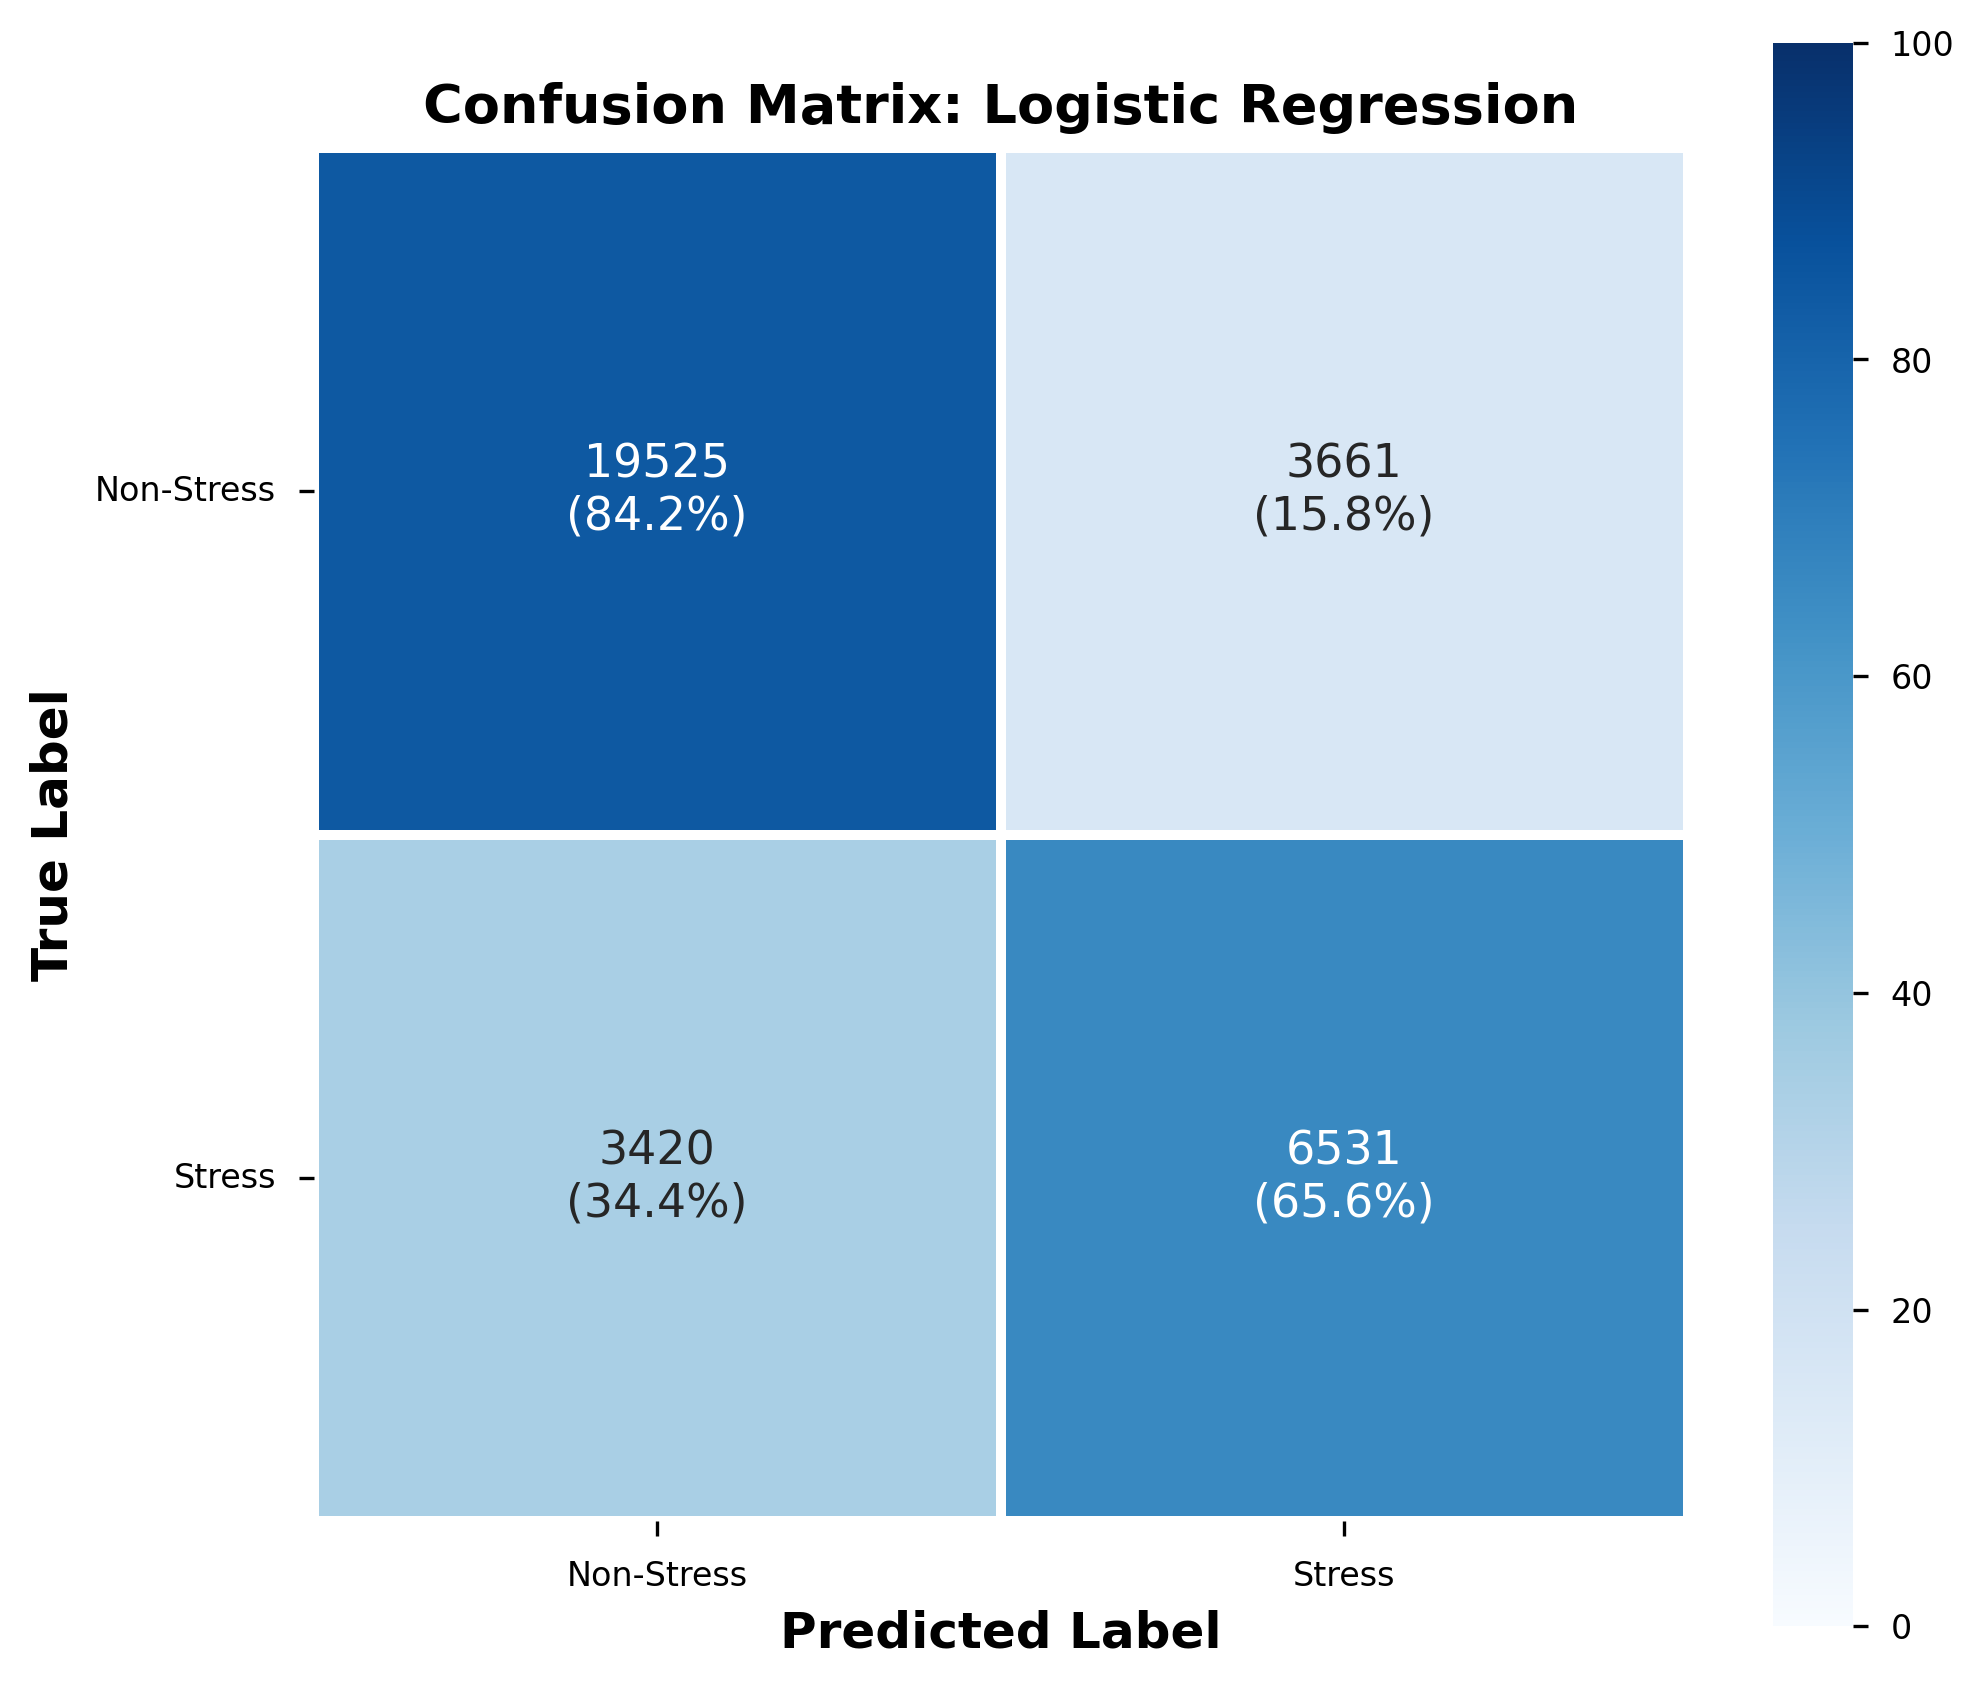

   ✓ Saved: fig_logistic_regression_cm.png


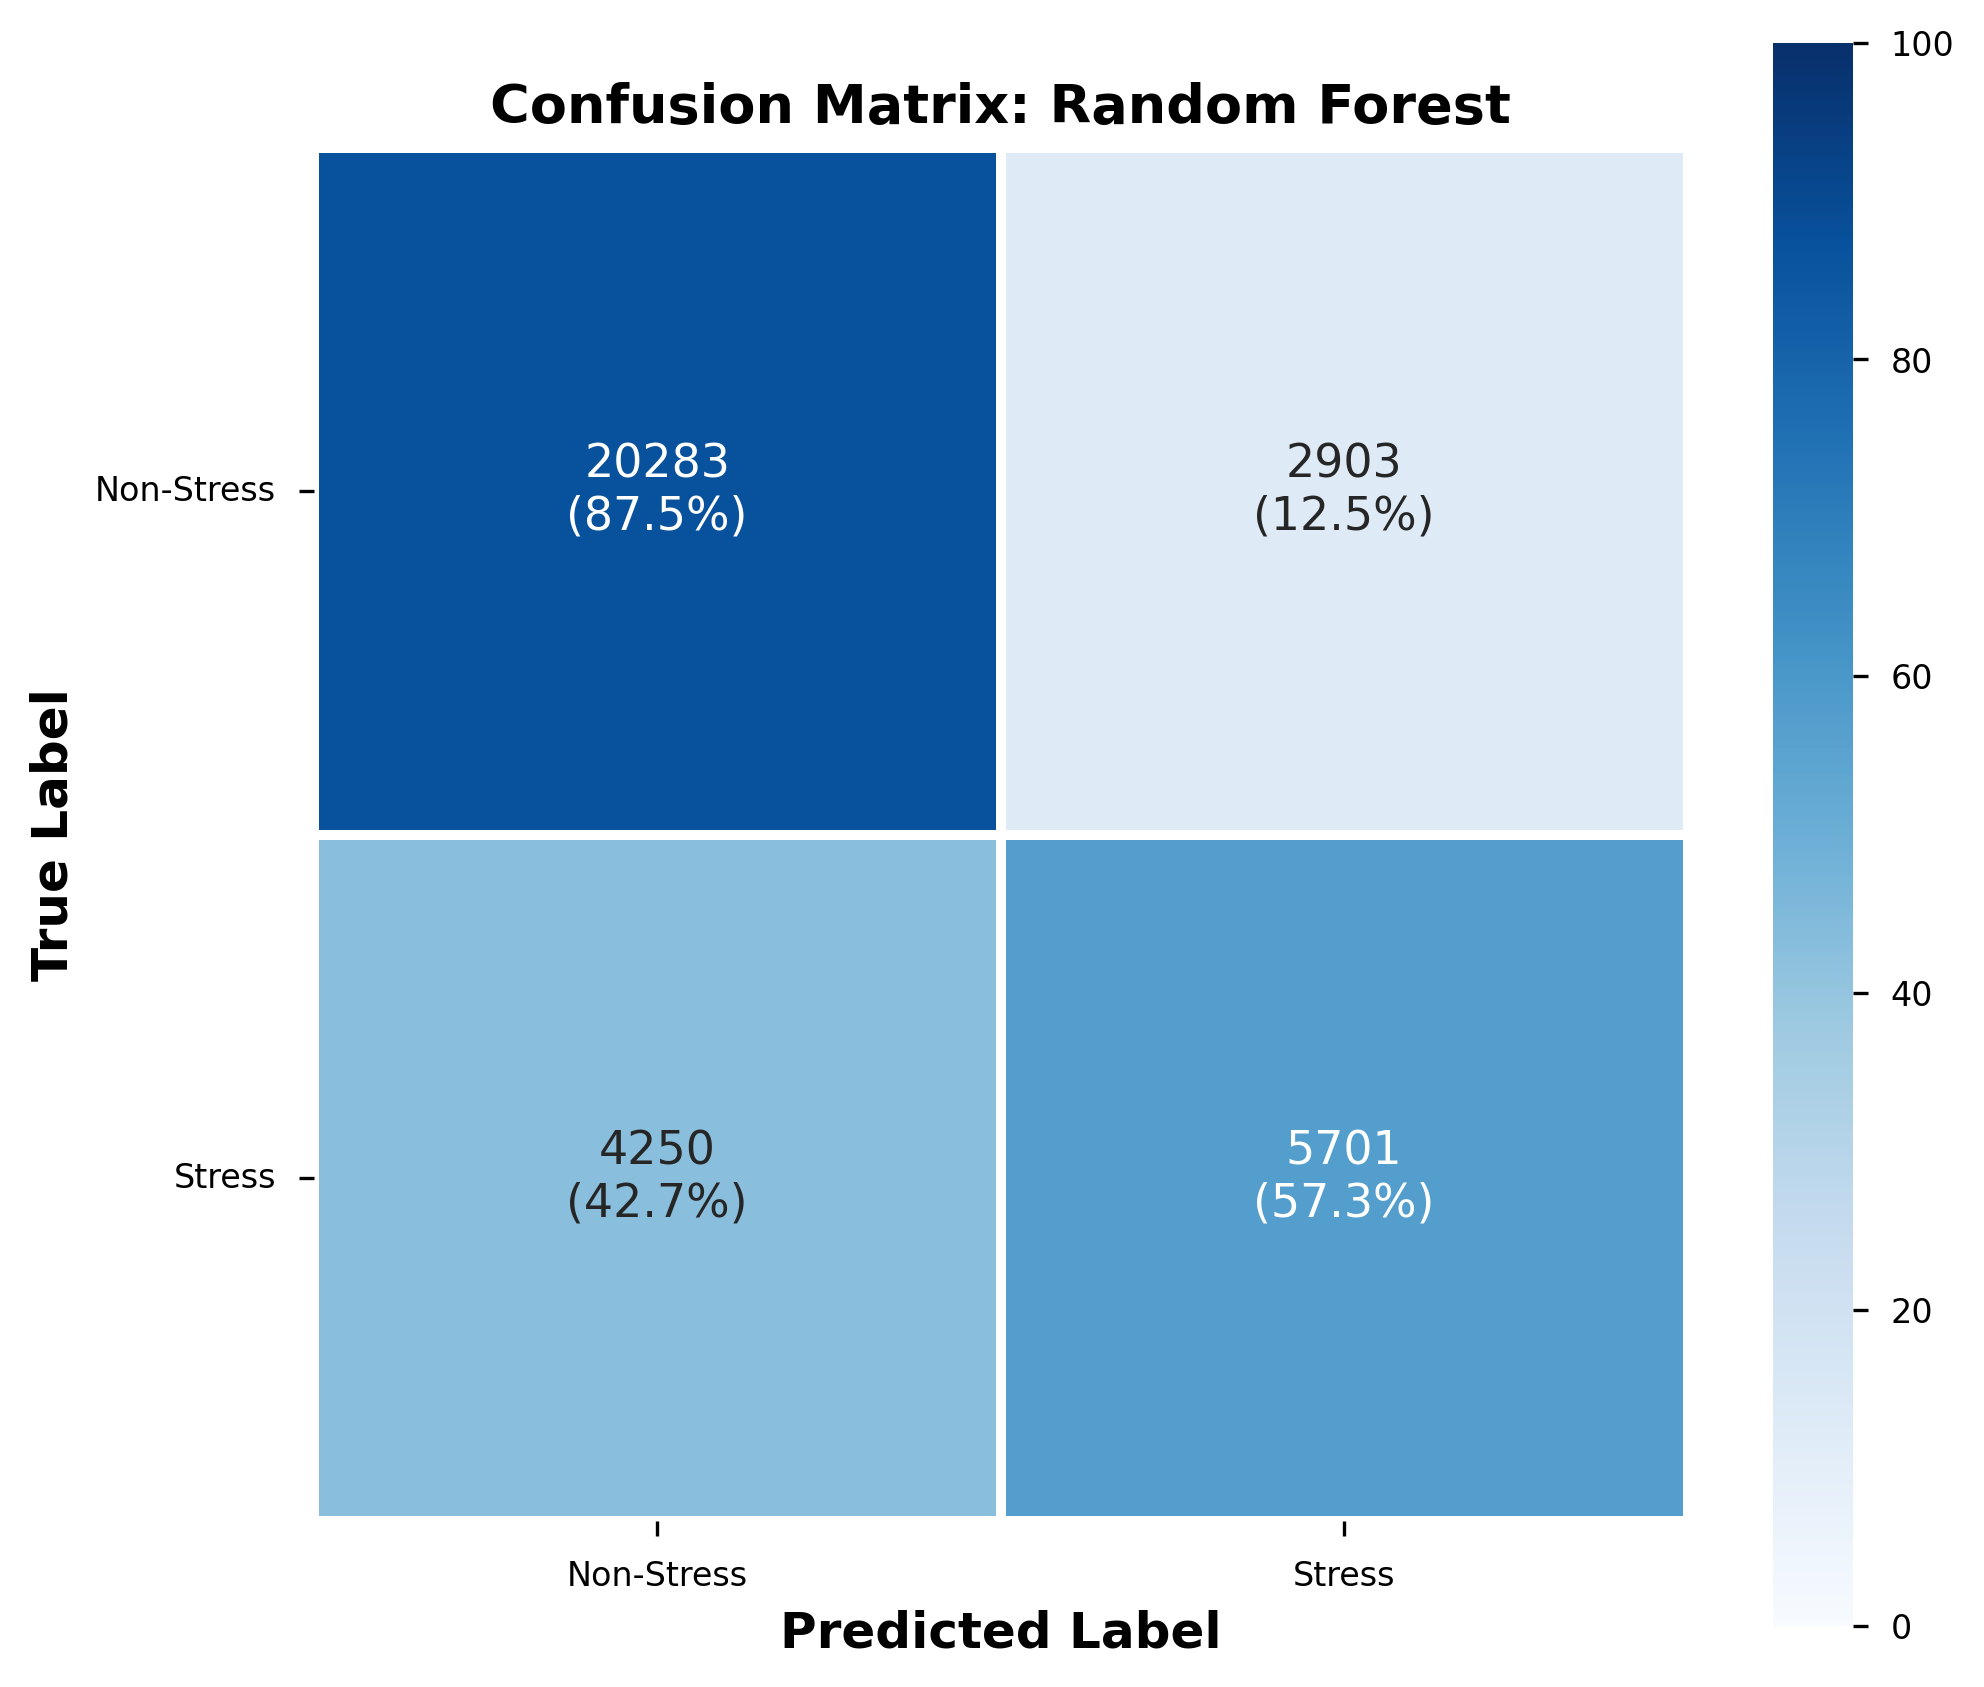

   ✓ Saved: fig_random_forest_cm.png


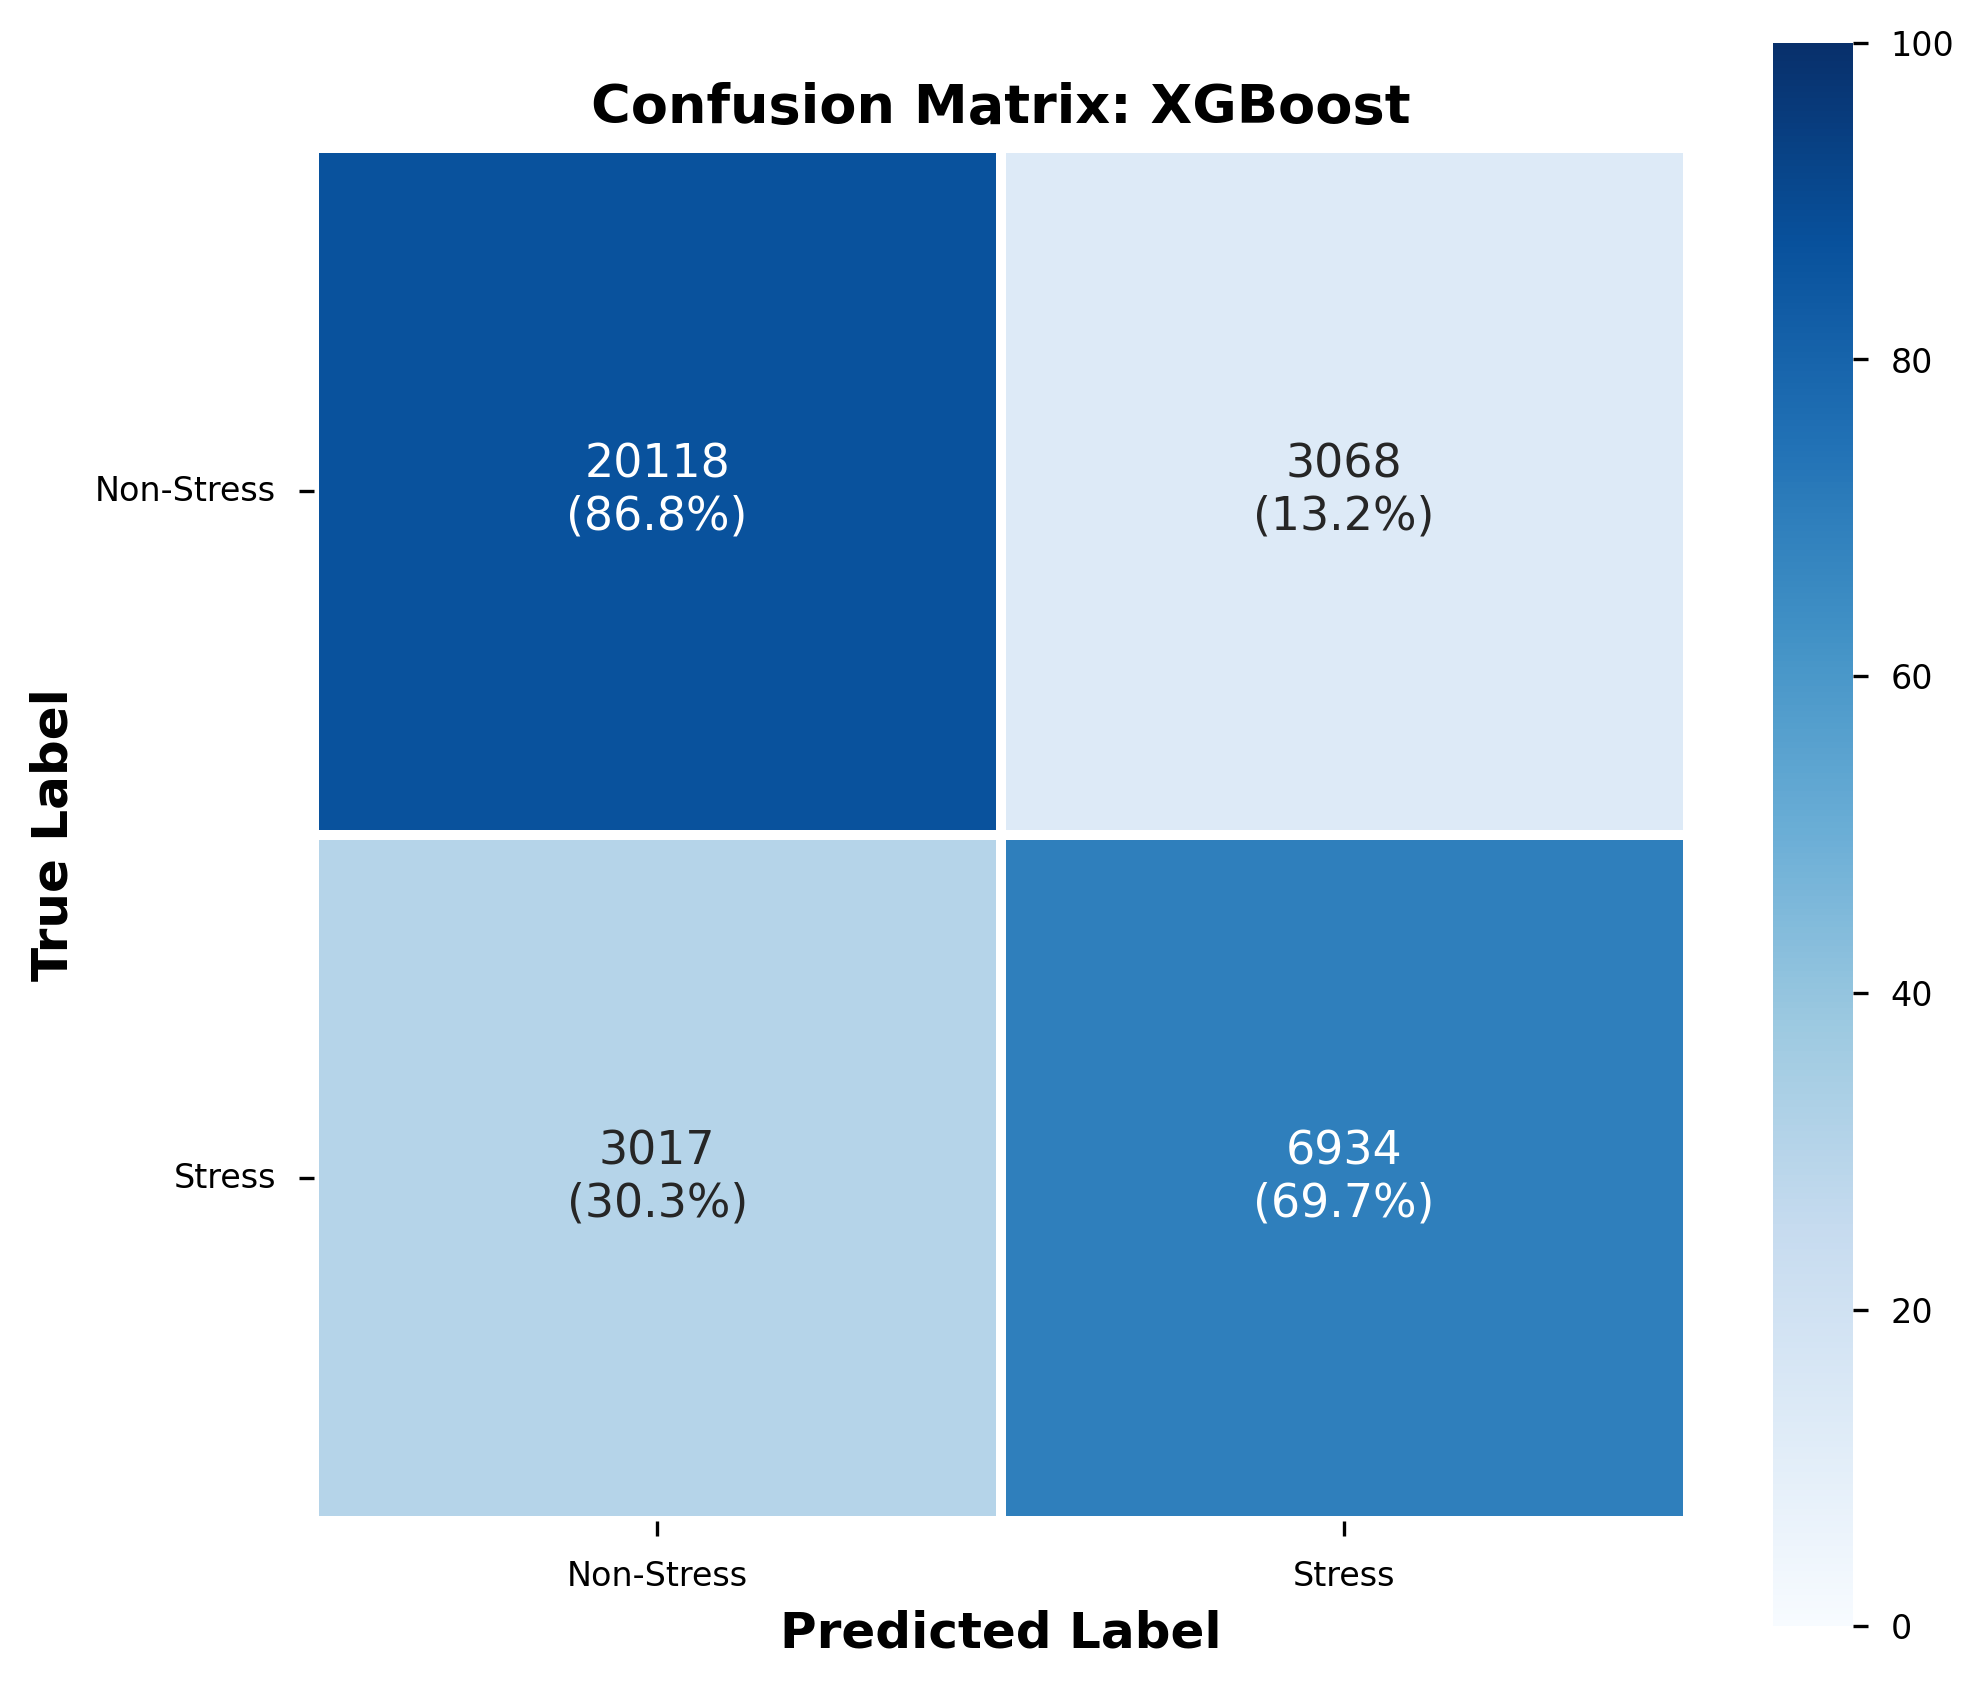

   ✓ Saved: fig_xgboost_cm.png

2. Generating ROC Curves...


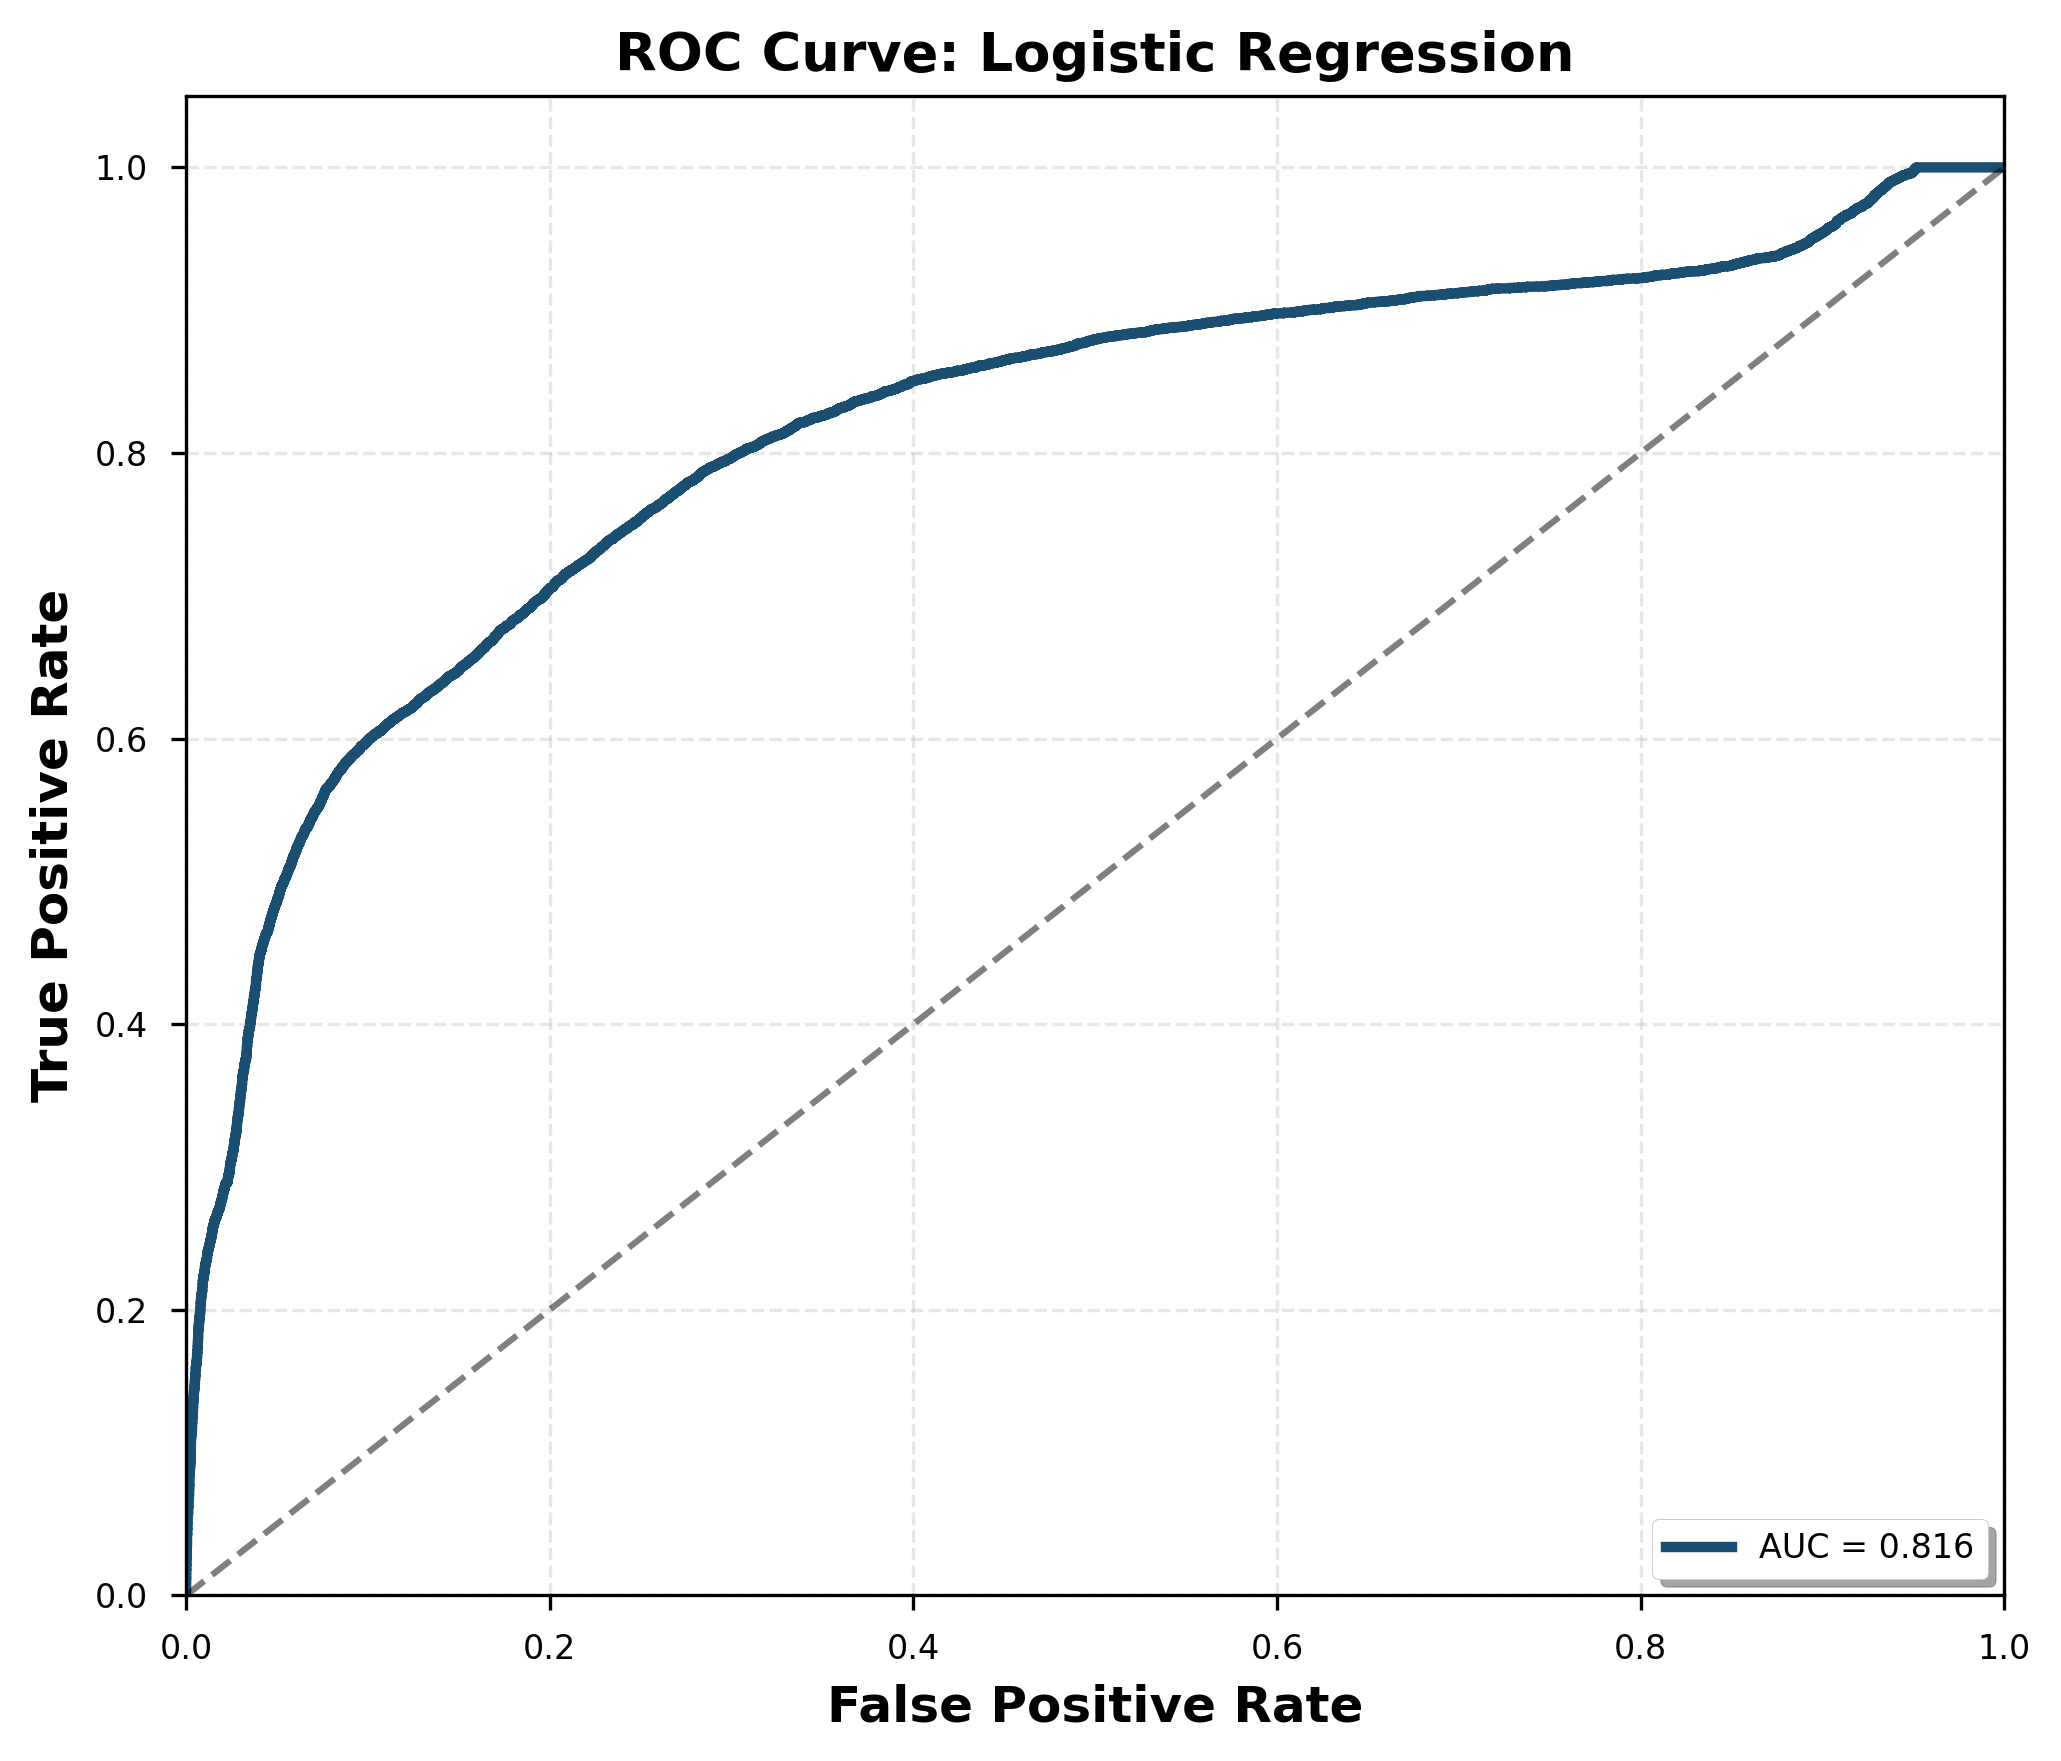

   ✓ Saved: fig_logistic_regression_roc.png


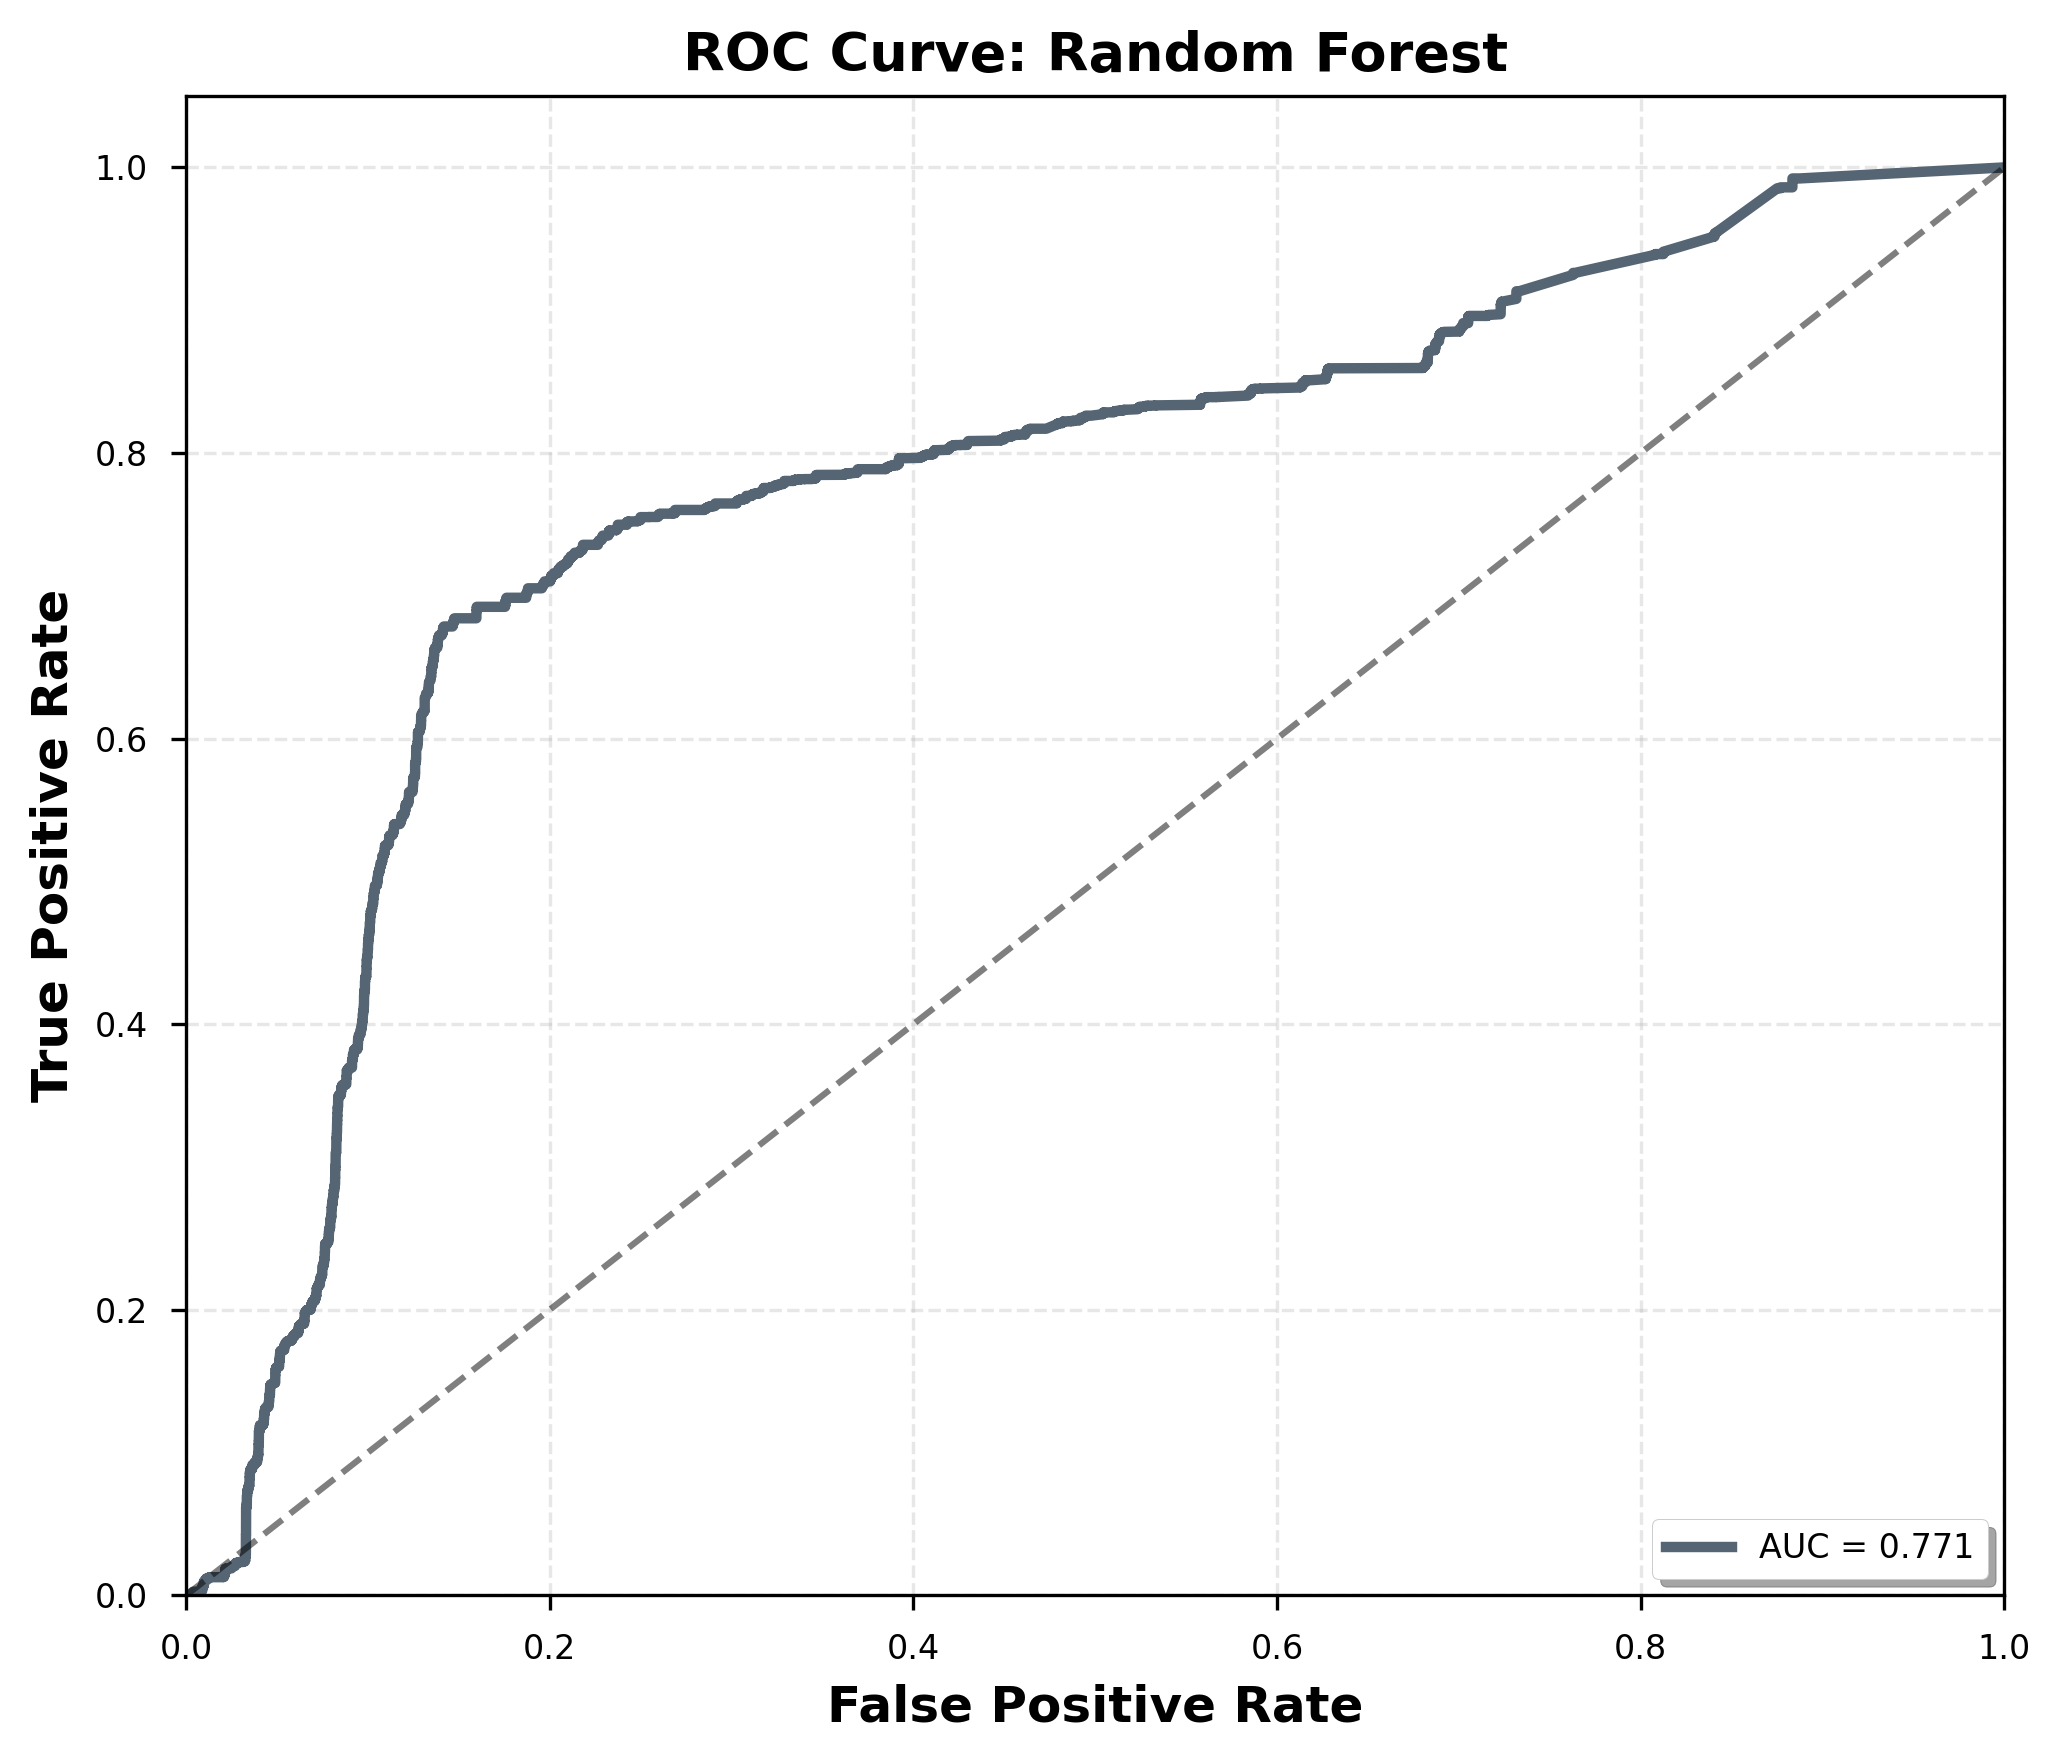

   ✓ Saved: fig_random_forest_roc.png


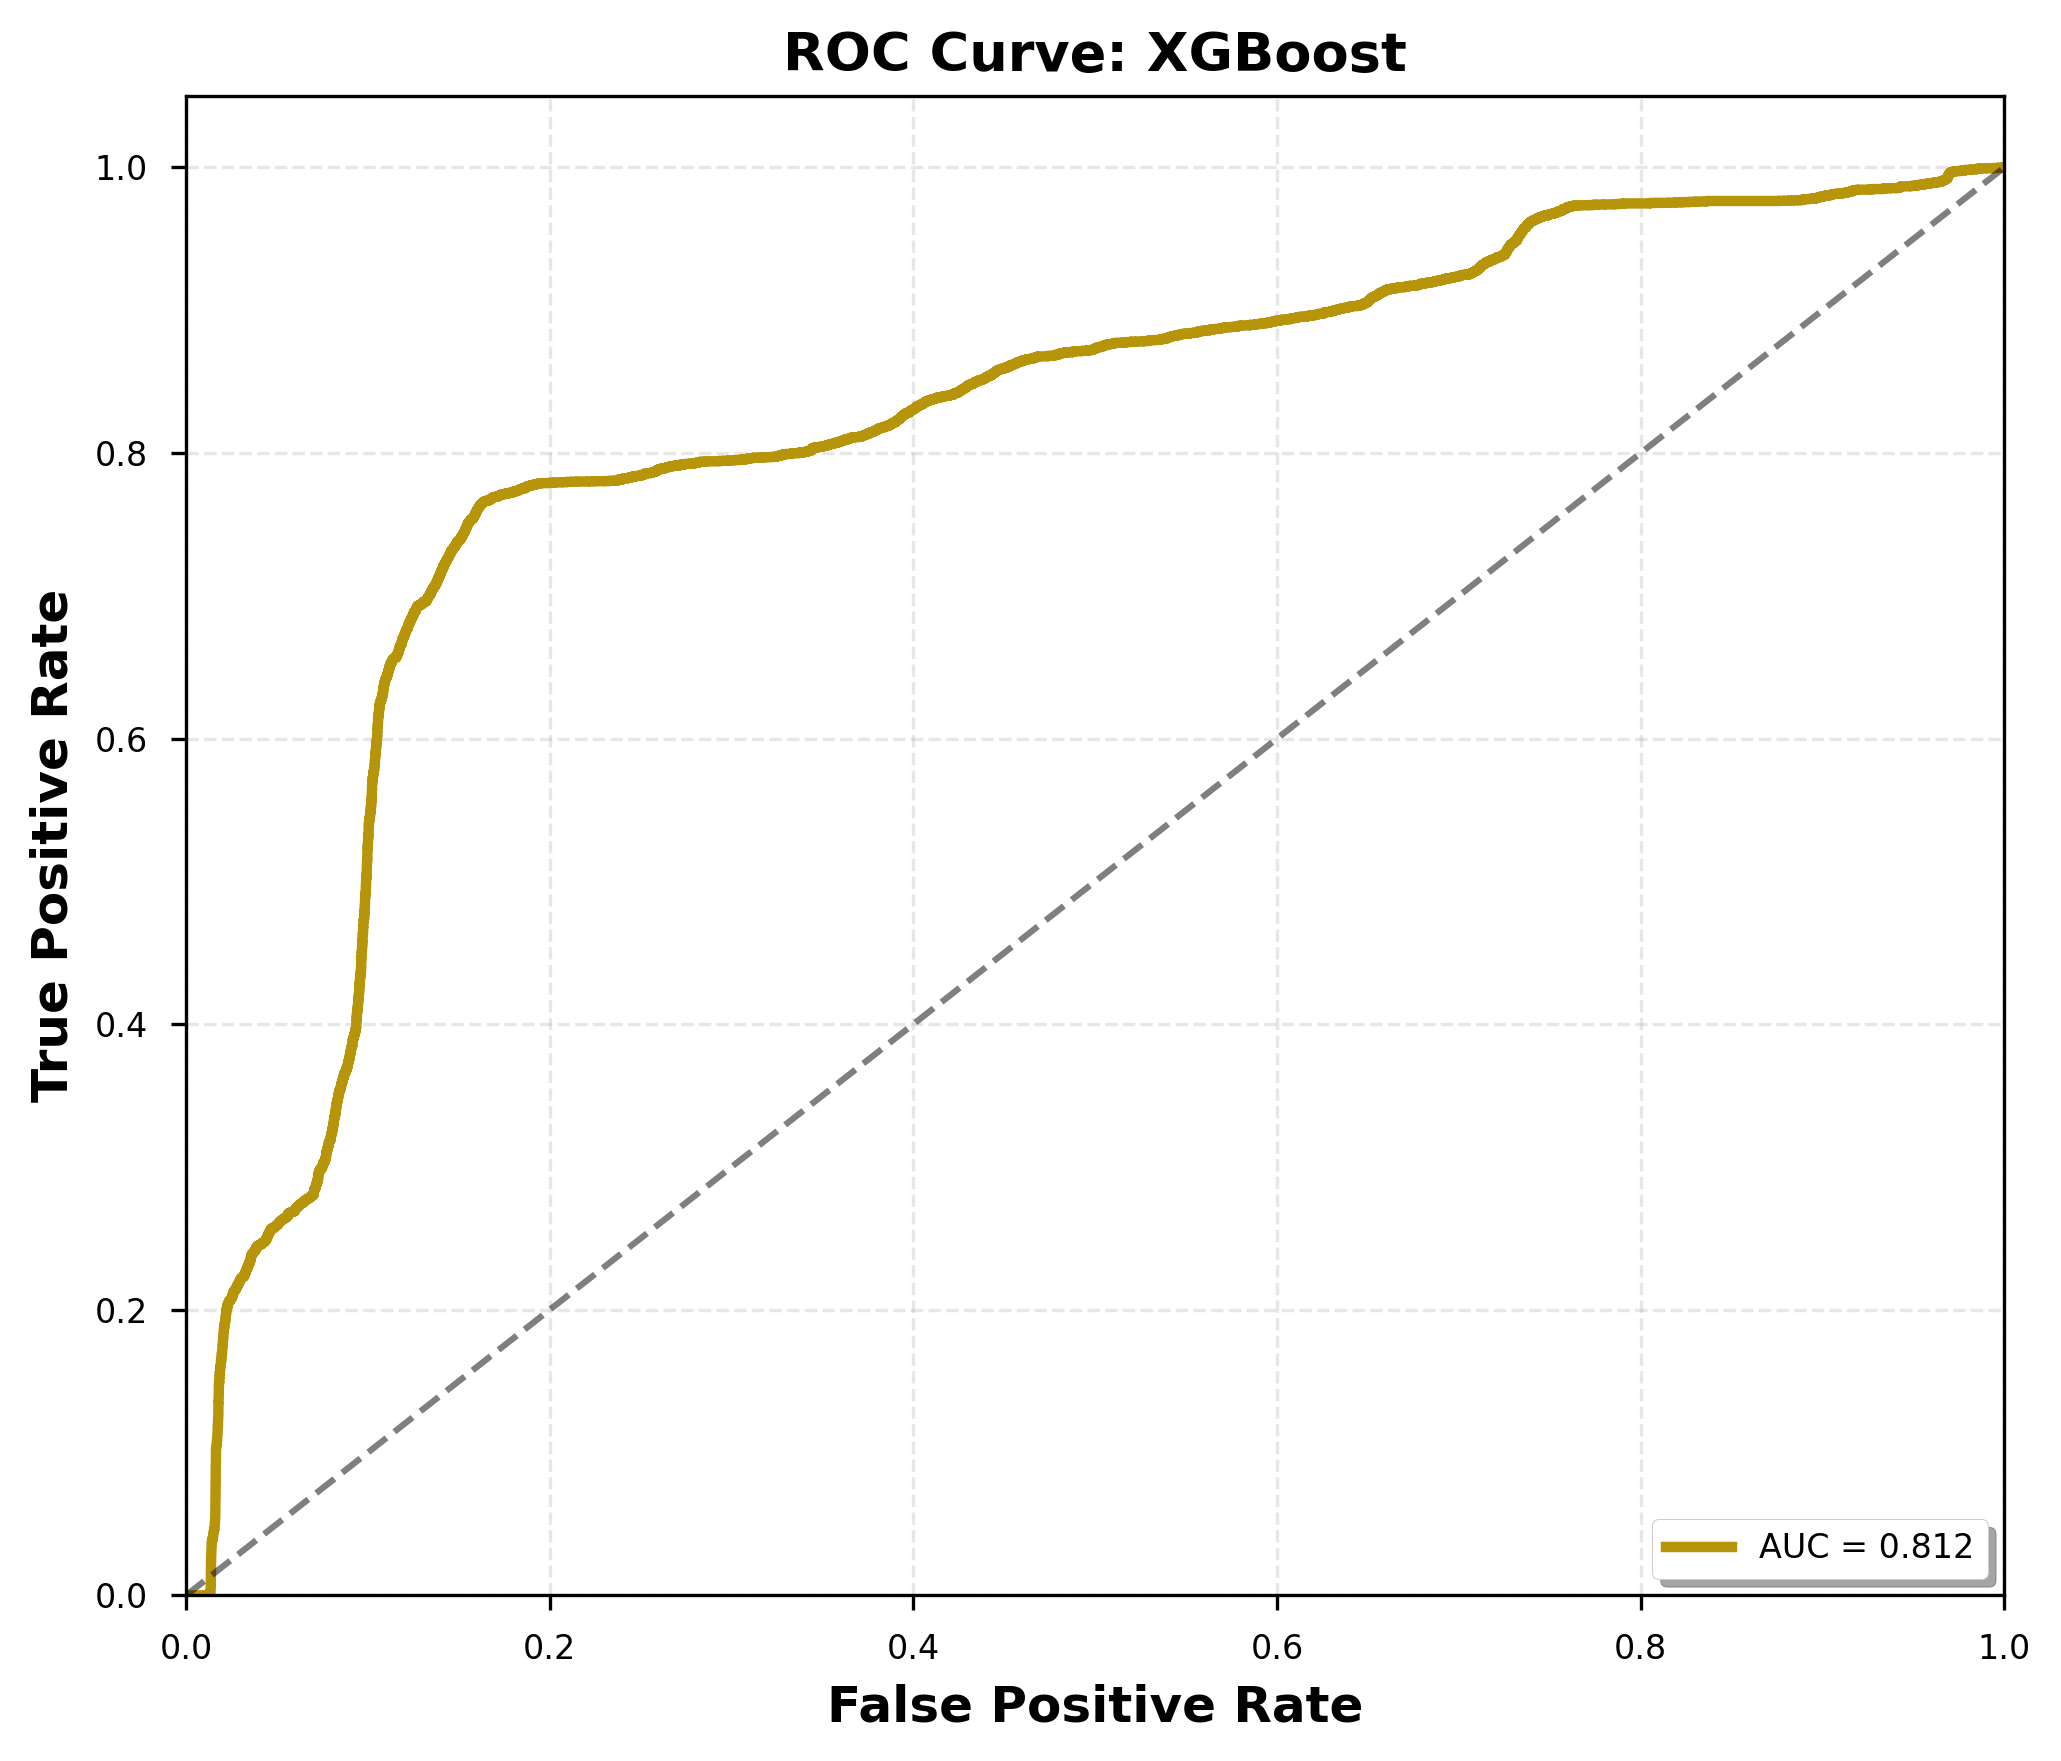

   ✓ Saved: fig_xgboost_roc.png

3. Generating Model Comparison Plots...


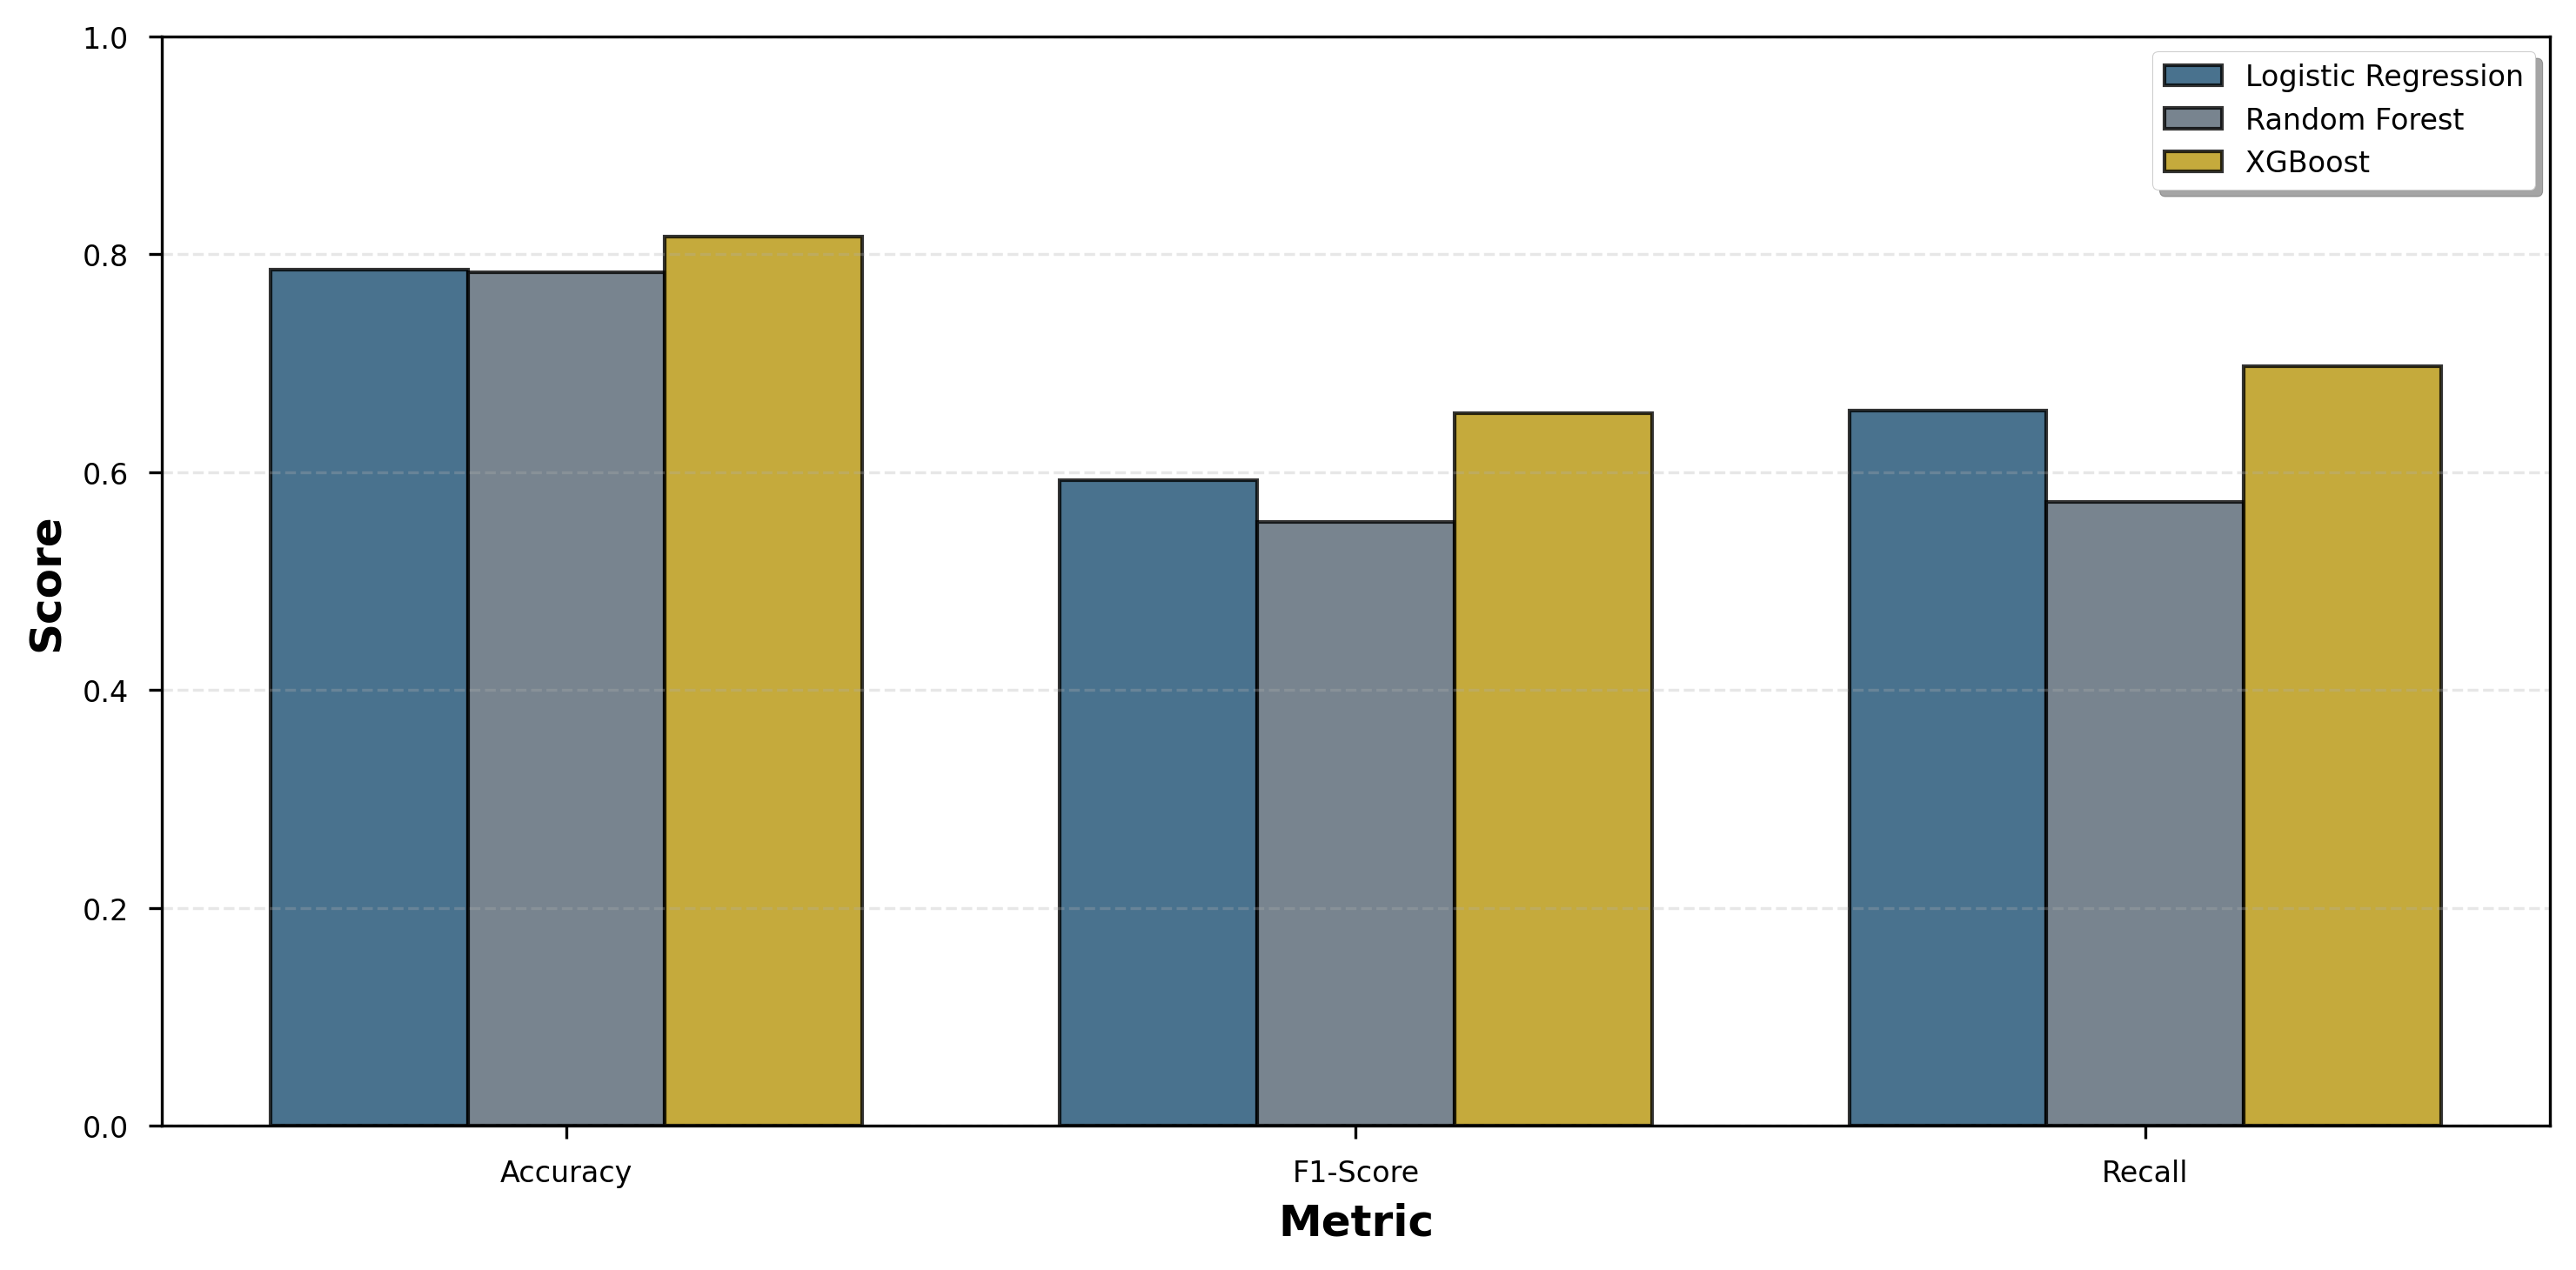

   ✓ Saved: fig_metrics_comparison.png

4. Generating XGBoost Feature Importance Plot...


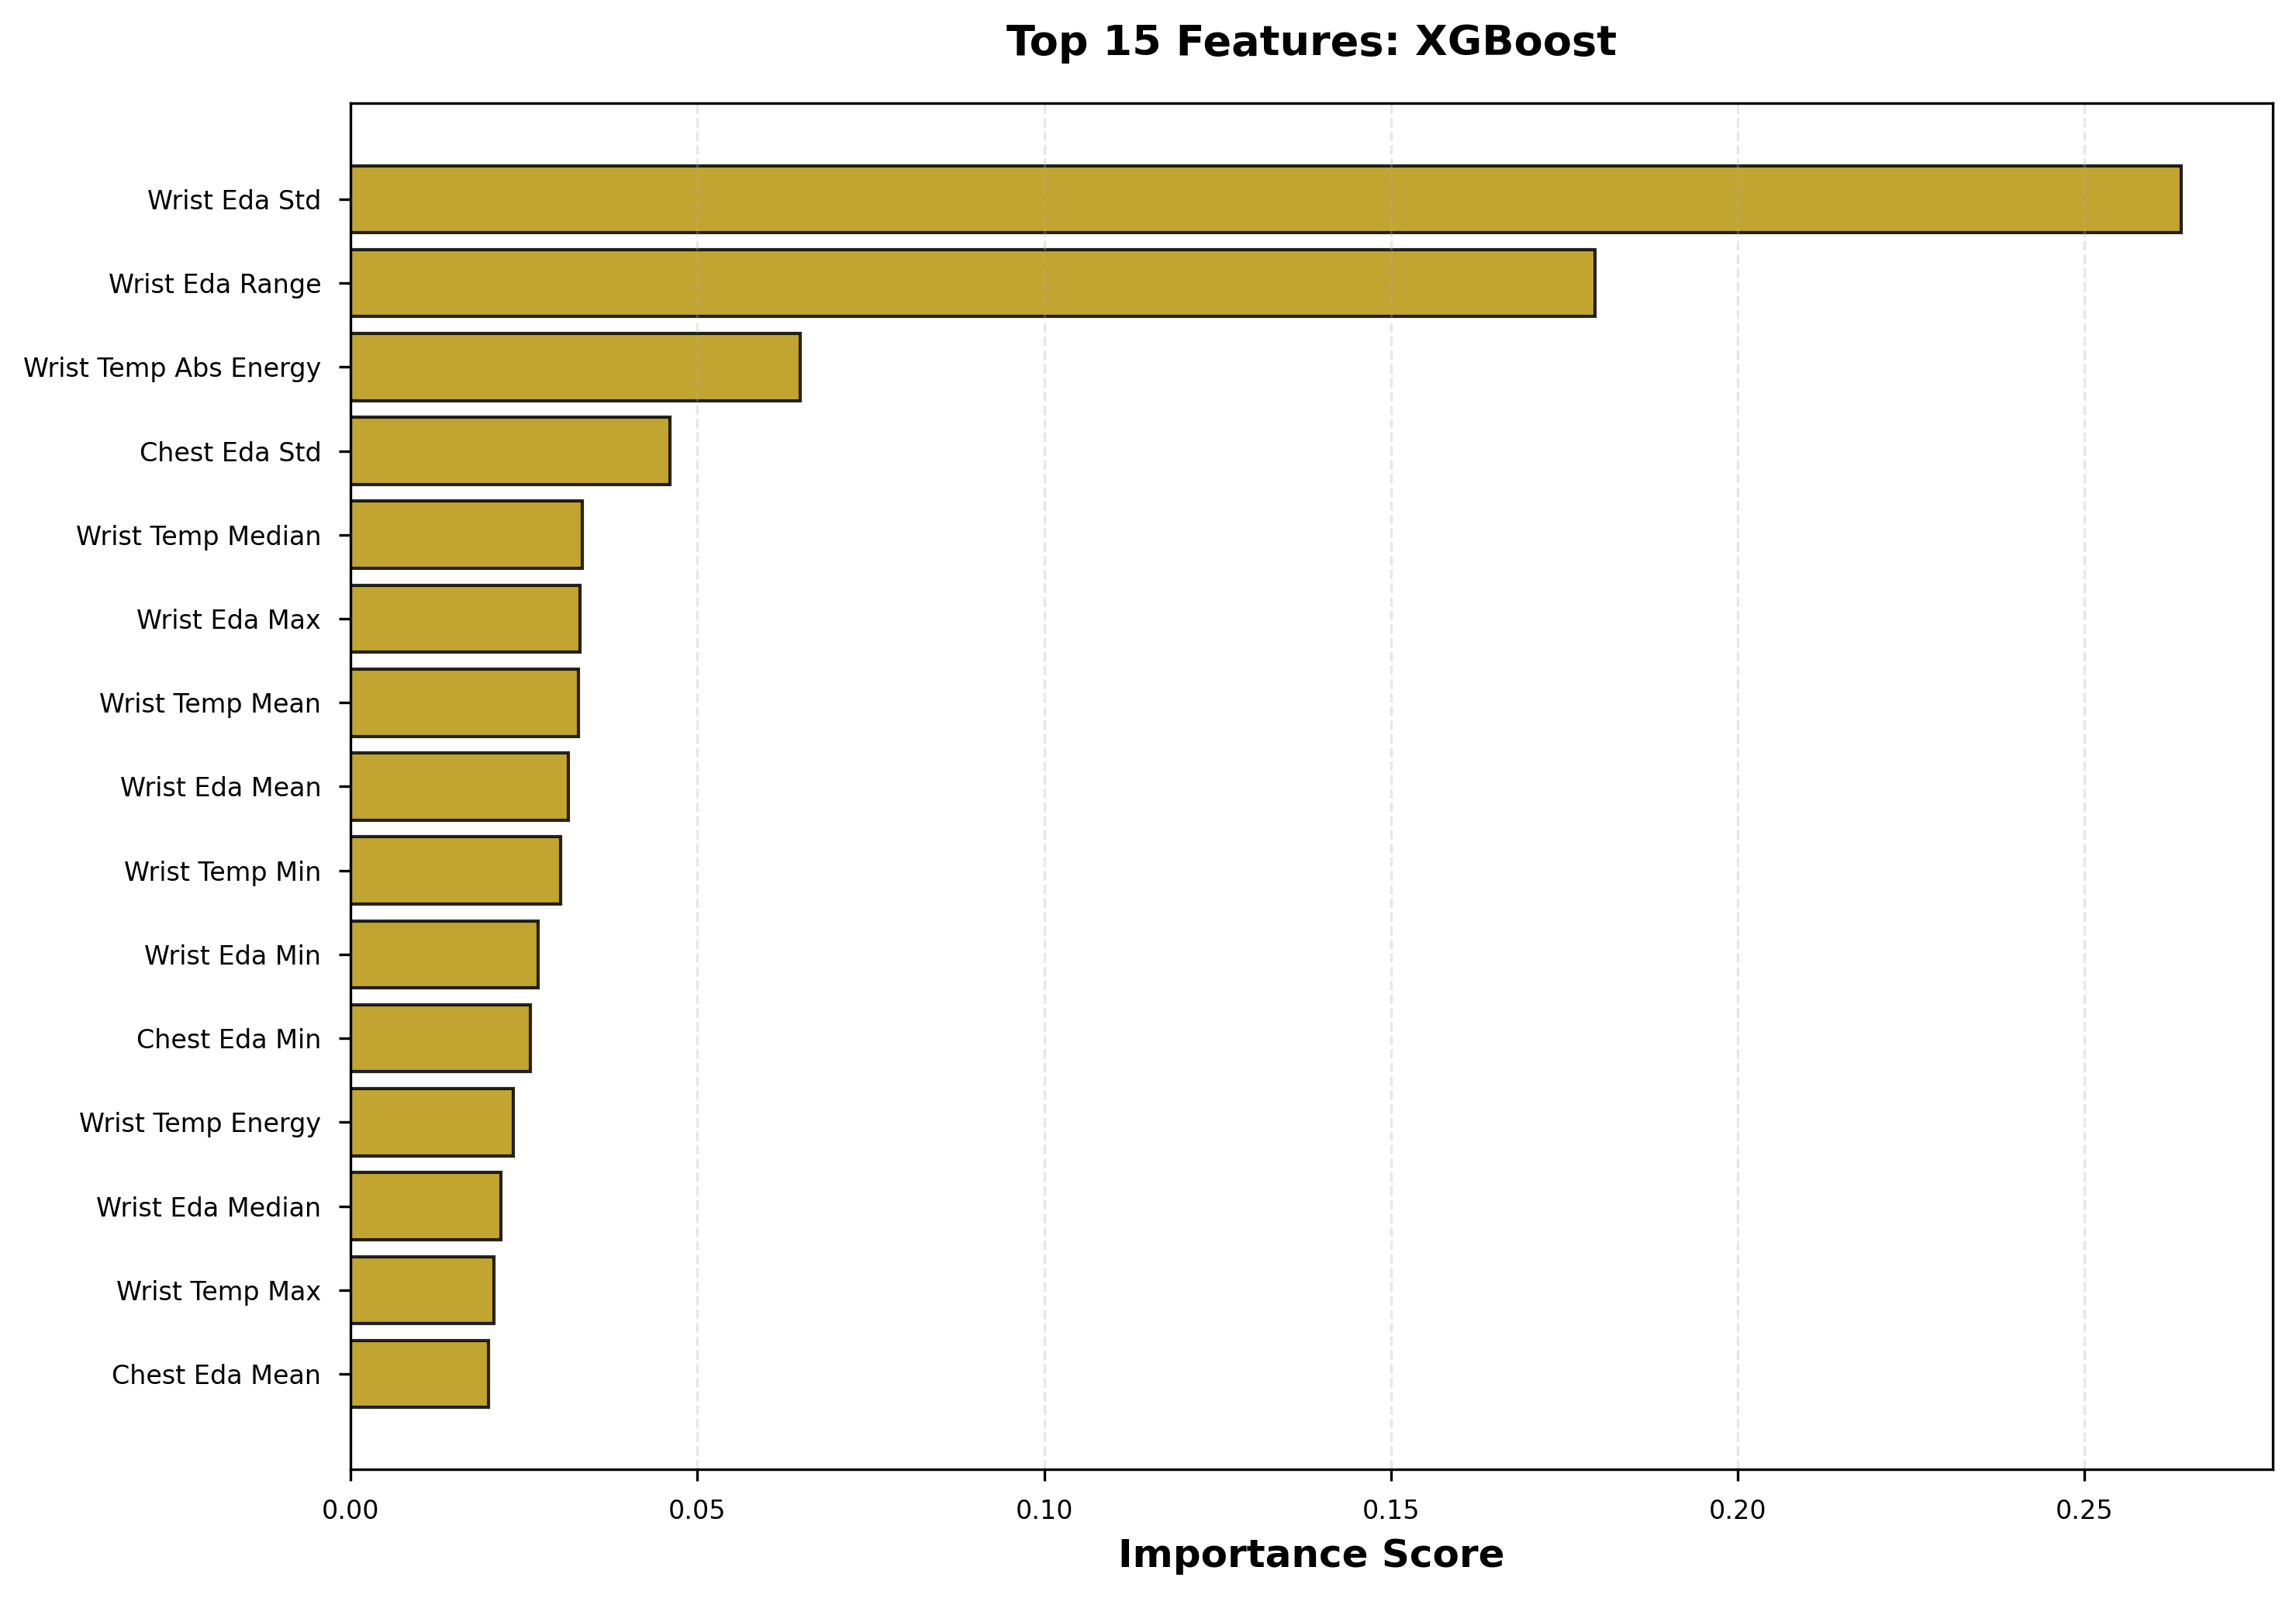

   ✓ Saved: fig_feature_importance.png

5. Generating Correlation Matrix...


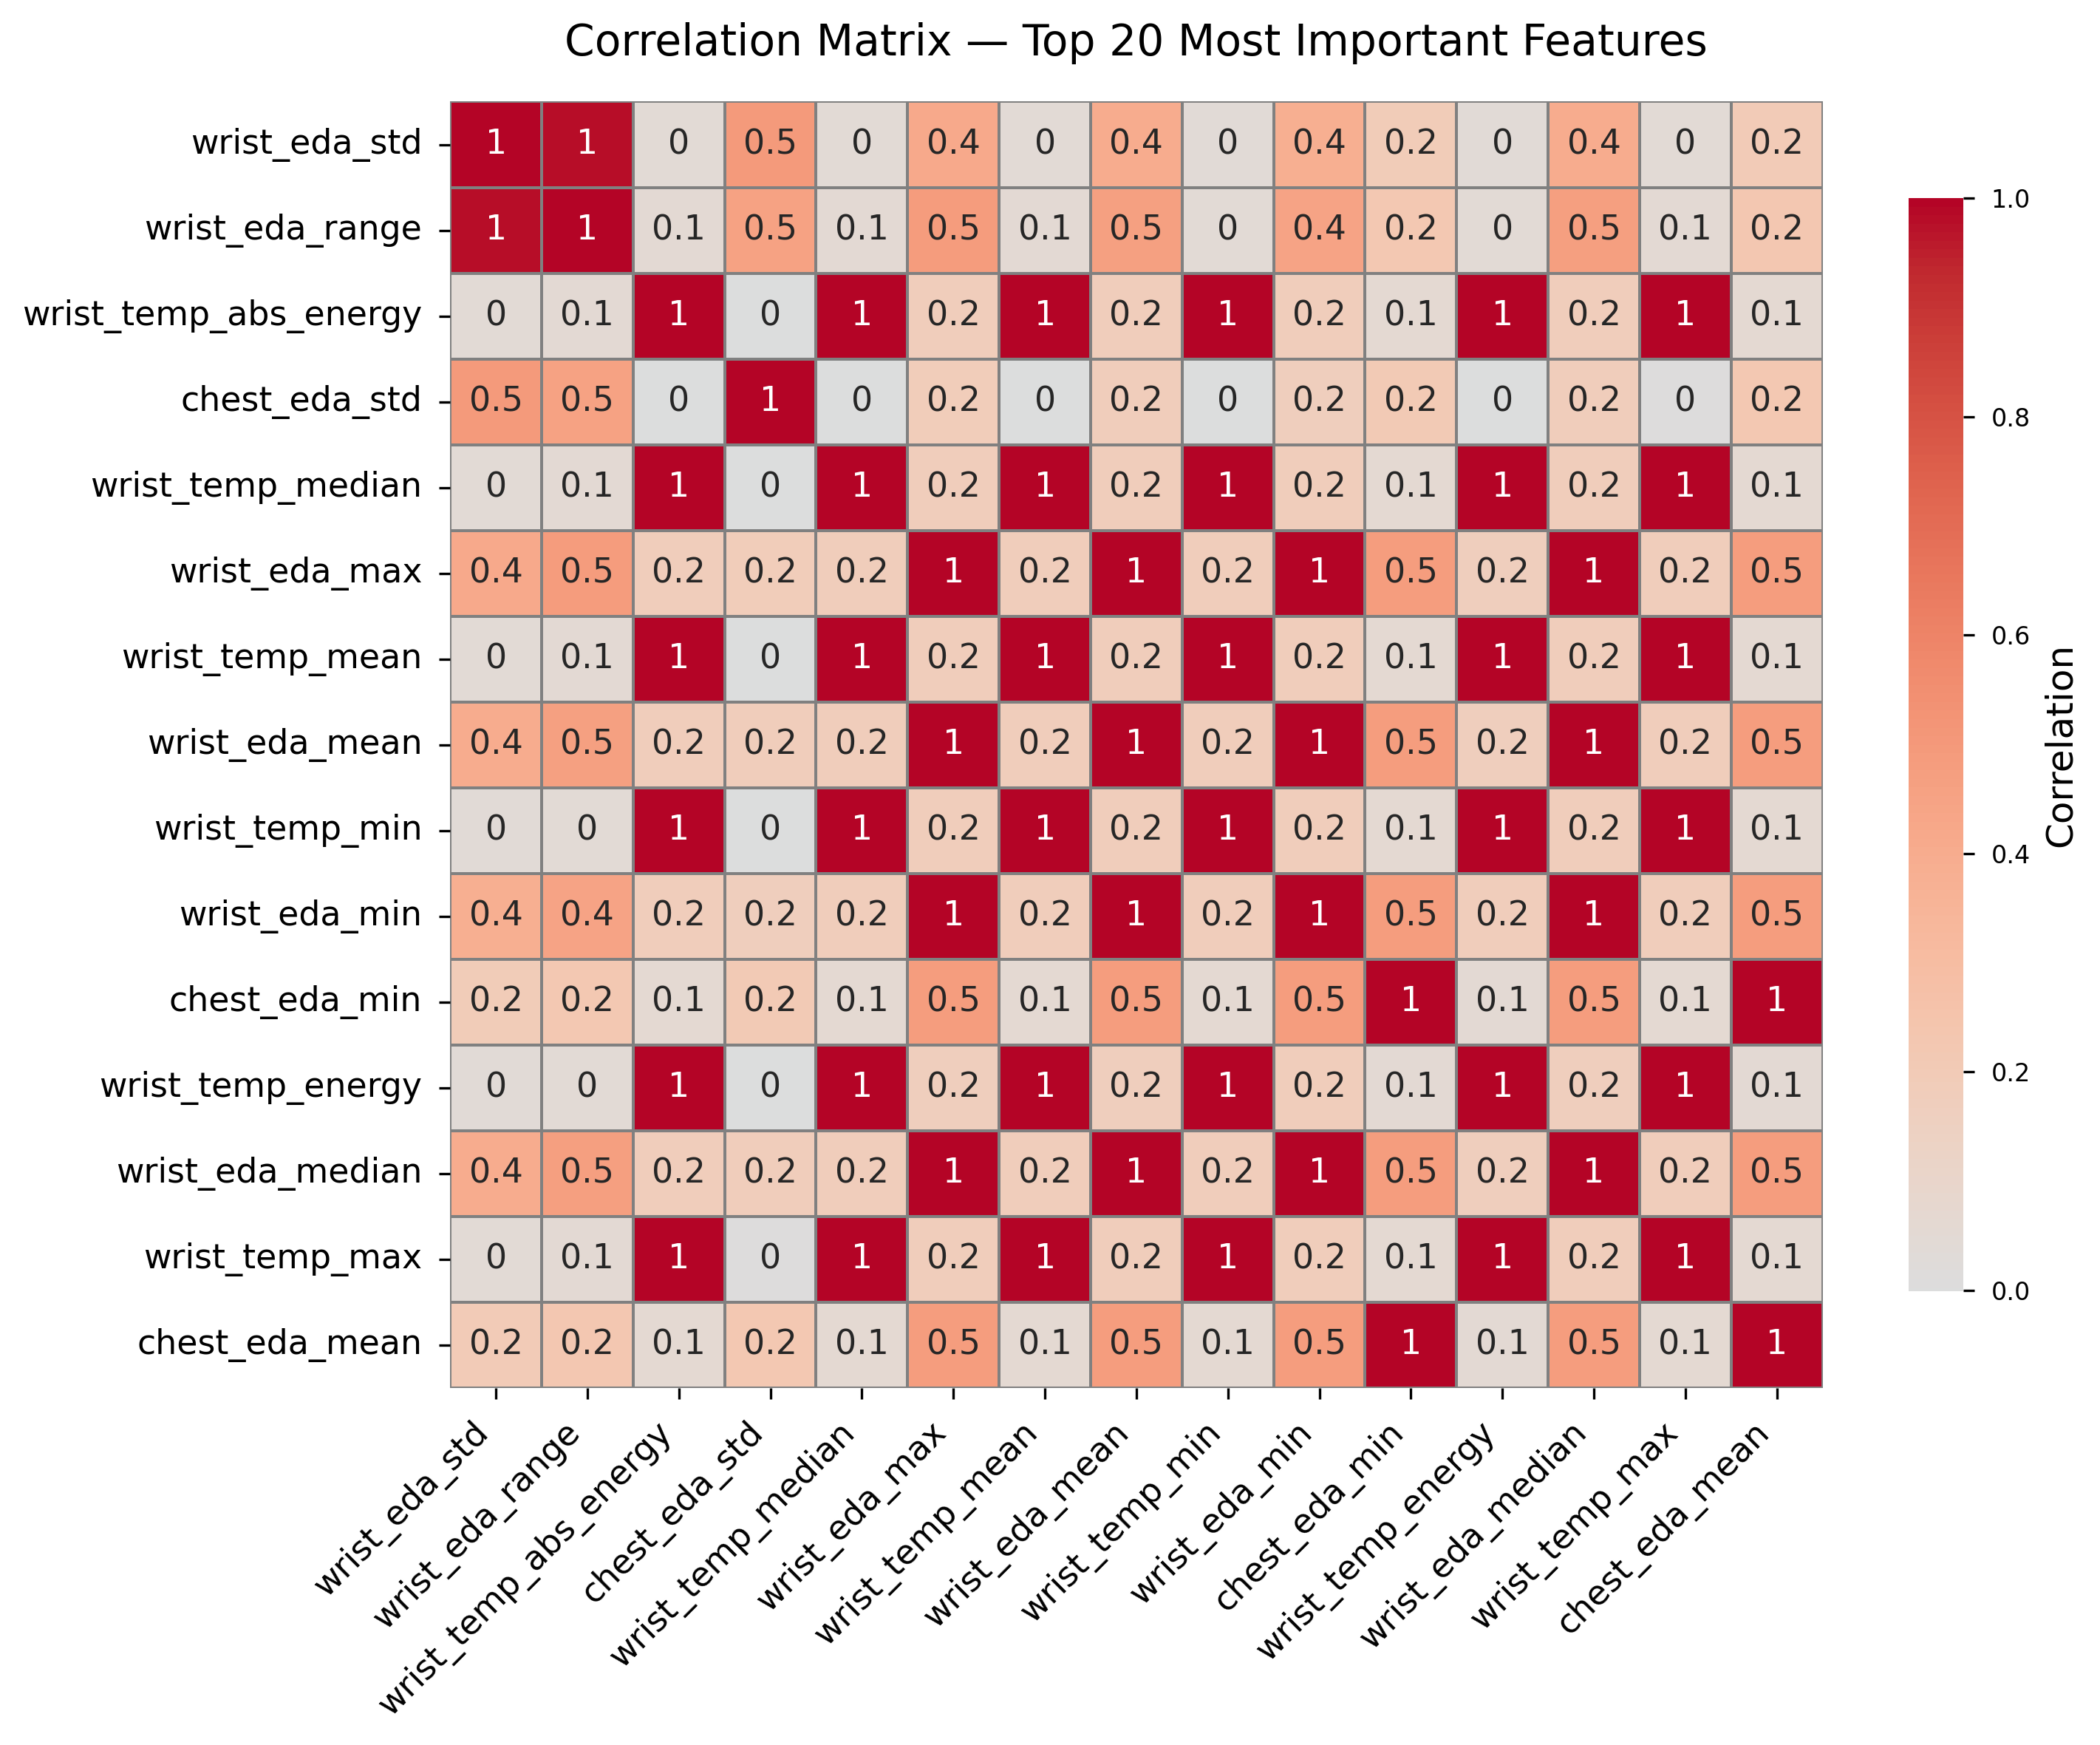

   ✓ Saved: fig_correlation_matrix.png

✓ ALL VISUALIZATIONS COMPLETE!

Generated files:
  • fig_logistic_regression_cm.png
  • fig_random_forest_cm.png
  • fig_xgboost_cm.png
  • fig_logistic_regression_roc.png
  • fig_random_forest_roc.png
  • fig_xgboost_roc.png
  • fig_metrics_comparison.png
  • fig_feature_importance.png
  • fig_correlation_matrix.png

📊 All figures are downloaded


In [ ]:
# =========================================================
# ROC/CM/Bar chart/feature Importance/Correlation Matrix
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
SEED = 42

# Publication-quality settings
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
})

# NEW PROFESSIONAL COLOR PALETTE
COLORS = {
    'Logistic Regression': '#1b4f72',   # deep navy
    'Random Forest': '#566573',         # slate grey
    'XGBoost': '#b7950b'                # gold
}


# =========================================================
# Helper Functions
# =========================================================

def init_model(model_class, class_weight_dict, scale_pos_weight=None, seed=SEED):
    """Initialize ML model with appropriate hyperparameters."""
    if model_class == LogisticRegression:
        return LogisticRegression(
            max_iter=5000, solver='lbfgs',
            class_weight=class_weight_dict, n_jobs=-1, random_state=seed
        )
    elif model_class == XGBClassifier:
        return XGBClassifier(
            n_estimators=350,
            max_depth=5,
            learning_rate=0.06,
            min_child_weight=2,
            subsample=0.9,
            colsample_bytree=0.9,
            gamma=0.05,
            reg_alpha=0.2,
            reg_lambda=1.5,
            scale_pos_weight=scale_pos_weight,
            eval_metric='logloss',
            random_state=seed,
            n_jobs=-1
        )
    elif model_class == RandomForestClassifier:
        return RandomForestClassifier(
            n_estimators=100, max_depth=10,
            class_weight='balanced',
            random_state=seed, n_jobs=-1
        )
    return model_class()


def get_loso_predictions(df, model_class):
    """
    Run LOSO and collect all predictions and probabilities.
    Returns y_true, y_pred, y_proba for visualization.
    """
    X = df.drop(columns=["label_bin", "subject_id"])
    y = df["label_bin"]
    groups = df["subject_id"]

    loso = LeaveOneGroupOut()

    all_y_true = []
    all_y_pred = []
    all_y_proba = []

    for train_idx, test_idx in loso.split(X, y, groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Skip if only one class in test
        if len(np.unique(y_test)) < 2:
            continue

        # Standardize
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Class weights
        classes = np.unique(y_train)
        weights = compute_class_weight('balanced', classes=classes, y=y_train)
        class_weight_dict = dict(zip(classes, weights))
        scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

        # Train model
        model = init_model(model_class, class_weight_dict, scale_pos_weight)
        model.fit(X_train_scaled, y_train)

        # Predictions
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)
        all_y_proba.extend(y_proba)

    return np.array(all_y_true), np.array(all_y_pred), np.array(all_y_proba)


def plot_confusion_matrix(df, model_class, model_name):
    """Plot confusion matrix only."""
    y_true, y_pred, _ = get_loso_predictions(df, model_class)

    fig, ax = plt.subplots(figsize=(7, 6))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(
        cm_percent,
        annot=np.array([[f'{cm[i,j]}\n({cm_percent[i,j]:.1f}%)'
                        for j in range(cm.shape[1])]
                       for i in range(cm.shape[0])]),
        fmt='',
        cmap='Blues',
        cbar=True,
        ax=ax,
        vmin=0,
        vmax=100,
        linewidths=2,
        linecolor='white',
        square=True
    )

    ax.set_title(f'Confusion Matrix: {model_name}', fontweight='bold')
    ax.set_xlabel('Predicted Label', fontweight='bold')
    ax.set_ylabel('True Label', fontweight='bold')
    ax.set_xticklabels(['Non-Stress', 'Stress'])
    ax.set_yticklabels(['Non-Stress', 'Stress'], rotation=0)

    plt.tight_layout()
    plt.savefig(f'fig_{model_name.replace(" ", "_").lower()}_cm.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"   ✓ Saved: fig_{model_name.replace(' ', '_').lower()}_cm.png")


def plot_roc_curve(df, model_class, model_name):
    """Plot ROC curve only."""
    y_true, _, y_proba = get_loso_predictions(df, model_class)

    fig, ax = plt.subplots(figsize=(7, 6))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr,
            color=COLORS[model_name],
            linewidth=2.5,
            label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1],
            'k--', linewidth=1.5, alpha=0.5)

    ax.set_xlabel('False Positive Rate', fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontweight='bold')
    ax.set_title(f'ROC Curve: {model_name}', fontweight='bold')
    ax.legend(loc='lower right', frameon=True, shadow=True)
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])

    plt.tight_layout()
    plt.savefig(f'fig_{model_name.replace(" ", "_").lower()}_roc.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"   ✓ Saved: fig_{model_name.replace(' ', '_').lower()}_roc.png")


# =========================================================
# Models List (UPDATED NAME)
# =========================================================
models_list = [
    (LogisticRegression, "Logistic Regression"),
    (RandomForestClassifier, "Random Forest"),
    (XGBClassifier, "XGBoost")
]

# =========================================================
# 1. Confusion Matrices
# =========================================================
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)
print("\n1. Generating Confusion Matrices...")

for model_class, model_name in models_list:
    plot_confusion_matrix(FUSION, model_class, model_name)

# =========================================================
# 2. ROC Curves
# =========================================================
print("\n2. Generating ROC Curves...")

for model_class, model_name in models_list:
    plot_roc_curve(FUSION, model_class, model_name)

# =========================================================
# 3. Model Comparison Plots (Accuracy, F1, Recall)
# =========================================================
print("\n3. Generating Model Comparison Plots...")

metrics_data = []
for result in all_results:
    model_name = result['model']
    metrics_data.append({
        'Model': model_name,
        'Metric': 'Accuracy',
        'Mean': result['accuracy_mean']
    })
    metrics_data.append({
        'Model': model_name,
        'Metric': 'F1-Score',
        'Mean': result['f1_mean']
    })
    metrics_data.append({
        'Model': model_name,
        'Metric': 'Recall',
        'Mean': result['recall_mean']
    })

metrics_df = pd.DataFrame(metrics_data)

metrics_df['Model'] = metrics_df['Model'].str.replace(r'\s*\(Optimized\)', '', regex=True).str.strip()

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(metrics_df['Metric'].unique()))
width = 0.25
multiplier = 0

for model_name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    model_data = metrics_df[metrics_df['Model'] == model_name]
    if model_data.empty:
        continue  # extra safety

    offset = width * multiplier

    ax.bar(
        x + offset,
        model_data['Mean'],
        width,
        label=model_name,
        color=COLORS[model_name],
        alpha=0.8,
        edgecolor='black',
        linewidth=1
    )

    multiplier += 1

ax.set_ylabel('Score', fontweight='bold')
ax.set_xlabel('Metric', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'F1-Score', 'Recall'])
ax.legend(loc='upper right', frameon=True, shadow=True)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('fig_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Saved: fig_metrics_comparison.png")

# =========================================================
# 4. XGBoost Feature Importance
# =========================================================
print("\n4. Generating XGBoost Feature Importance Plot...")

loso = LeaveOneGroupOut()
train_idx, _ = next(loso.split(FUSION, FUSION["label_bin"], FUSION["subject_id"]))

X_train = FUSION.iloc[train_idx].drop(columns=["label_bin", "subject_id"])
y_train = FUSION.iloc[train_idx]["label_bin"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Class weights
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

xgb_model = init_model(XGBClassifier, class_weight_dict, scale_pos_weight)
xgb_model.fit(X_train_scaled, y_train)

# Top 15 features
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False).head(15)

feature_importance_df['Feature_Clean'] = \
    feature_importance_df['Feature'].str.replace('_', ' ').str.title()

plt.figure(figsize=(10, 7))
bars = plt.barh(
    feature_importance_df['Feature_Clean'],
    feature_importance_df['Importance'],
    color=COLORS['XGBoost'],
    alpha=0.85,
    edgecolor='black',
    linewidth=1
)

plt.xlabel('Importance Score', fontweight='bold')
plt.title('Top 15 Features: XGBoost', fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Saved: fig_feature_importance.png")

# =========================================================
# 5. Correlation Matrix (TOP 20 FEATURES WITH ANNOTATION)
# =========================================================
print("\n5. Generating Correlation Matrix...")

# Top 20 by importance
top20_features = (
    feature_importance_df.sort_values(by="Importance", ascending=False)
    .head(20)['Feature'].values
)

corr = FUSION[top20_features].corr()

# Custom annotation formatting (same as previous version)
def annot_fmt(val):
    rounded = round(val, 1)
    if np.isclose(rounded, 1.0) or np.isclose(rounded, -1.0) or np.isclose(rounded, 0.0):
        return f"{int(rounded)}"
    else:
        return f"{rounded:.1f}"

labels = np.array([[annot_fmt(val) for val in row] for row in corr.values])

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=labels,
    fmt="",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"shrink": 0.85, "label": "Correlation"},
    annot_kws={"size": 11}
)

plt.xticks(fontsize=11, rotation=45, ha="right")
plt.yticks(fontsize=11, rotation=0)
plt.title("Correlation Matrix — Top 20 Most Important Features", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("fig_correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Saved: fig_correlation_matrix.png")
# =========================================================
# SUMMARY
# =========================================================
print("\n" + "="*60)
print("✓ ALL VISUALIZATIONS COMPLETE!")
print("="*60)

print("\nGenerated files:")
print("  • fig_logistic_regression_cm.png")
print("  • fig_random_forest_cm.png")
print("  • fig_xgboost_cm.png")
print("  • fig_logistic_regression_roc.png")
print("  • fig_random_forest_roc.png")
print("  • fig_xgboost_roc.png")
print("  • fig_metrics_comparison.png")
print("  • fig_feature_importance.png")
print("  • fig_correlation_matrix.png")

print("\n📊 All figures are downloaded")